# 01 — The limit: excluded $(m_\text{DM}, \alpha_n)$ regions

**Paper element.** Supplemental Material, Supplementary Limit Figures:
`01_excluded_massless` (the excluded region per mode for a massless mediator).
The same released surfaces sit behind the left panel of the Letter's results
figure.

**What this notebook is.** The paper's result, end to end: the 95% CL exclusion
limits for ultraheavy dark matter coupling to neutrons through a finite-range
Yukawa mediator, from the POLONAISE levitated-magnet impulse search. The
observed candidates are handled by the public
[`optimum_interval`](https://github.com/tunnell/optimum_interval) package
(Yellin optimum-interval; no background model needed). Four things in order: the
excluded region for the reference range and for a massless mediator, the whole
released range family, the refined boundary against the grid it came from, and
the three sensor modes compared on the mass plane — then, from the release's
mediator-range sidecar, the $(\alpha_n, \lambda)$ plane of the mode that
sidecar carries.

**Sensor modes.** Every panel figure below shows all three sensor modes side by
side; the remaining single-mode figures use `MODE_NUMBER` (set below: 1, 2, or
3). Each mode's inputs — the reconstructed impulse candidates
`data_mode{n}.txt` and the detection efficiency $\varepsilon(q)$, both shown and
checked in
[`00_data_and_selection.ipynb`](00_data_and_selection.ipynb) — are folded into
the rate. Section 4 puts all three modes on one plane;
[`04_composite_benchmark.ipynb`](04_composite_benchmark.ipynb) combines them
with the atmosphere switched off.

**Fiducials** (threshold, live-time and $R_\text{eff}$ from `luhdm.config`): momentum threshold
$q_\text{th}$ = 1 TeV/$c$, live-time $T$ = 219.66 h (the measured dataset
exposure, `config.T_EXPOSURE`), sensor radius $R_\text{eff}$ = 260 µm, SHM halo
with atmospheric attenuation, and this species taken as $f_\mathrm{DM}$ = 1 of the local
dark-matter density. That last choice is now a property of the *file*: the release ships one hypothesis per file and this notebook opens
`luhdm_datarelease_v10_A_f1_atm.h5`, the $f_\mathrm{DM}$ = 1, atmosphere-on
plane. The three physics mediator ranges $\lambda$ = 2 mm, 200 µm and 20 µm,
plus the analytic massless ($\lambda\to\infty$) limit, are drawn below; the
axis also carries a 200 m convergence-check slice, which is not a physics point
and is not drawn. Couplings up to $\alpha_n = 1$; masses up to the Planck mass.
The mediator range is scanned continuously — 54 finite ranges from 0.1 µm to
2 m — in the release's own companion file `luhdm_lambda_scan_v10.npz`, which
section 5 draws. That sidecar is scanned for the modes it names, and this
release scans mode 1.

**The mass window.** Two edges of every region below come from outside the
extremeness surface. On the left, a hard kinematic wall at
$m_\text{wall} = q_\text{th}/v_\text{max} = 3.80\times10^{5}$ GeV, where
$v_\text{max} = v_\text{esc} + v_E$ = 789 km/s is the fastest arrival this
release's lab-frame halo supports: no lighter particle can deliver a 1 TeV kick
at any coupling. On the right, the flux cut
$m_\text{cut}$: the impact-parameter integral is **uncapped** in this release,
so the surfaces keep reporting exclusion at masses where the halo delivers
almost no flybys through the apparatus, and the region is closed instead by
requiring $N_\text{req} = 3$ expected transits within 10 cm during the exposure
— **an assumption**, stated in the file's `m_cut_*` attributes and marked on
every mass-axis figure below. Nothing in the cube applies it for you. Both edges
are taken apart in [`03_the_edges.ipynb`](03_the_edges.ipynb).

**Which boundary is the limit.** The Letter quotes the *refined* boundary of
section 3 — root-found on the same statistic — not the contour of the stored
grid. At 0.233 dex per coupling cell the grid contour is a drawing convention,
and section 3 shows how far the two differ.

**Output:** the figures below; every surface and contour behind them is
available in the POLONAISE UHDM data release (see
[`05_using_the_data_release.ipynb`](05_using_the_data_release.ipynb)), so
nothing needs digitizing.

Companion notebook:
[`02_how_the_limit_is_made.ipynb`](02_how_the_limit_is_made.ipynb) — the physics
and statistics pipeline, with validations, including the projection kernel these
surfaces were built with. All surfaces below come from the POLONAISE UHDM
**data release** (file A of the current release — see the version tag in the
file / `release/README.md`), read through `luhdm.release`.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, units
from luhdm import release

# File A of the released pair: f_DM = 1 with atmospheric attenuation, the
# plane the Letter quotes its alpha_n limits on. Its lambda axis carries the
# three physics ranges, the 200 m convergence slice and the massless sentinel.
# This file is also luhdm.release.DEFAULT_PATH, so opening it by name here and
# opening it by default elsewhere read the same cube.
rel = release.open_release("../release/luhdm_datarelease_v10_A_f1_atm.h5")

# The halo frame is a property of the file, so it is read off the file and
# applied to luhdm.config before anything below uses a halo speed: this
# release is built in the LAB frame (v_earth = 245 km/s), where the arrival
# distribution reaches v_esc + v_E rather than v_esc. The kinematic wall
# below is the first thing that depends on it.
config.set_v_earth_km_s(rel.v_earth_km_s)

R_eff = config.R_EFF             # 260 um
Q_THRESH = config.Q_THRESH          # 1 TeV analysis threshold
T_TOTAL = config.T_EXPOSURE     # dataset live-time; env-overridable via
                                 # LUHDM_T_EXPOSURE, currently the
                                 # night-selection exposure (219.66 h)
CONFIDENCE = 0.95
# Presentation convention for the Letter: every limit we quote is at a dark
# matter fraction f_DM = 1. Only the composite-DM benchmark departs from it
# (notebook 04, f_DM = 0.1, which is file B). File A carries the f_DM = 1
# plane and nothing else, so this is threaded into every rel.* call below
# rather than left to the loader default -- that default is the build-side
# baseline 0.1, which is not on this file's axis at all.
F_DM = 1.0
F_DM_TXT = r"$f_\mathrm{DM}$ = 1"
M_PLANCK = 1.22e19               # GeV
M_WALL = Q_THRESH / config.V_MAX  # kinematic wall, GeV: no lighter mass can
                                 # deliver a threshold kick at any coupling.
                                 # V_MAX = v_esc + v_E is the fastest arrival
                                 # this file's halo frame supports
# the halo flux cut that closes every region on the right. Stored as an
# attribute rather than baked into the surfaces, because the N_req = 3
# transits-within-10-cm standard it assumes is a choice, not a measurement.
M_CUT = next(float(v) for k, v in rel.attrs.items()
             if k.startswith("m_cut_") and k.endswith("_gev"))
N_REQ = float(rel.attrs["m_cut_n_transits_required"])
# x-axis top for the mass figures: one partial decade past m_Pl, so the
# Planck marker line falls inside the frame instead of on the right spine
XMAX_MASS = 3e19                 # GeV

# the release's three finite mediator ranges, largest first. The family is
# ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2mm", "200um", "20um"]
_LAMBS = [2e-3, 2e-4, 2e-5]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = set()                     # every released range is drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          zorder=1.5,   # under contour lines: halo must not notch them
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


def mark_m_cut(ax, m_cut=None, y=0.985):
    # the flux cut: right-hand edge of every region drawn here. Everything to
    # its right is a statement about a flux the halo does not deliver.
    import matplotlib.patheffects as _pe
    m_cut = M_CUT if m_cut is None else m_cut
    ax.axvline(m_cut, color="#8c564b", lw=1.3, ls=(0, (6, 3)), zorder=1)
    txt = ax.text(m_cut, y, r"$m_{\mathrm{cut}}$ ", color="#8c564b",
                  fontsize=9, ha="right", va="top", rotation=90,
                  zorder=1.5,   # under contour lines: halo must not notch them
                  transform=ax.get_xaxis_transform())
    txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                          _pe.Normal()])


def mark_planck_mass(ax, m_pl=M_PLANCK, y=0.015, va="bottom"):
    # the mass grid stops at the Planck mass: mark that endpoint (label inside)
    import matplotlib.patheffects as _pe
    ax.axvline(m_pl, color="#555555", lw=1.3, ls=":", zorder=1)
    txt = ax.text(m_pl, y, r"$m_{\mathrm{Pl}}$", color="#555555",
                  fontsize=9, ha="right", va=va, rotation=90,
                  zorder=1.5,   # under contour lines: halo must not notch them
                  transform=ax.get_xaxis_transform())
    txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                          _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, stamp=None, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube (pass stamp= for a figure drawn from
    # some cube other than the released one this notebook opens)
    fig.text(0.995, 0.004,
             f"POLONAISE UHDM data release {stamp or rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

print(f"halo frame: v_earth = {rel.v_earth_km_s:g} km/s"
      + ("  (Galactic rest frame)" if rel.v_earth_km_s == 0.0
         else "  (lab frame)")
      + f"   v_max = v_esc + v_E = {config.V_MAX * units.C_M_S / 1e3:.0f} km/s")
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_DM = {F_DM:g} "
      f"(file axis {rel.f_dm_values})")
print(f"mass window: kinematic wall {M_WALL:.3g} GeV .. flux cut "
      f"{M_CUT:.3g} GeV (N_req = {N_REQ:g} transits within "
      f"{rel.attrs['m_cut_b_cap_m']:g} m -- an assumption, see "
      f"release/README.md section 5.4)")

# --------------------------------------------------------------------------- #
# Absorbed from the former mode-comparison notebook: the encoding and the
# helpers the three-mode figures of section 4 need.
#
# hue = mode (1 blue / 2 orange / 3 reddish-purple, Okabe-Ito), the same hue in
# every figure the mode appears in; shade = mediator range (long range dark ->
# short range light); line style = range. Green is deliberately not in the set,
# so no red guide line can end up adjacent to a green curve. The hues are
# written out here rather than imported from scripts/paper_style.py, whose
# import switches matplotlib to Agg and would kill the inline backend.
# --------------------------------------------------------------------------- #
import colorsys

import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

from luhdm import limits

ALL_MODES = (1, 2, 3)
PLOT_MODES = (1, 2, 3)   # edit to (1,), (2, 3), ... to draw a subset
BASE = {1: "#0072B2", 2: "#E69F00", 3: "#CC79A7"}

# the scheme this notebook assumes, checked against the file rather than
# trusted: the 1 TeV analysis window and an uncapped impact-parameter integral
assert float(rel.attrs["q_thresh_gev"]) == float(config.Q_THRESH), \
    "this cube was built for a different analysis window"
assert rel.b_constrained_max is None, \
    "this cube caps the impact-parameter integral; this notebook needs the uncapped release"

B_CAP = float(rel.attrs["m_cut_b_cap_m"])
CUT_TXT = (f"assumes {N_REQ:g} expected transits\n"
           f"within {B_CAP * 100:.0f} cm during the exposure")
Q_MIN_TEV = float(rel.attrs["q_thresh_gev"]) / 1e3
Q_MIN_TXT = rf"$q_{{\rm min}}$ = {Q_MIN_TEV:g} TeV"
XMIN_MASS = 2.5e5     # a little room left of the kinematic wall

# The mediator ranges of the three-mode figures are read off the file's own
# lambda axis rather than listed here, so a reissue on a different axis cannot
# silently drop one. Ordered by physical range (long -> short) with massless
# first. The long-range slice is a convergence check rather than a physics case,
# so it is named and skipped.
CONVERGENCE_LAMBDA_M = 2e2
_PRETTY = {"2m": "2 m", "20cm": "20 cm", "2cm": "2 cm", "2mm": "2 mm",
           "200um": "200 µm", "20um": "20 µm", "10um": "10 µm", "2um": "2 µm"}
# line styles from https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html
_STYLE_CYCLE = [(0, (3, 5, 1, 5)),     # dashdotted
                (0, (5, 5)),           # dashed
                (0, (3, 1, 1, 1)),     # densely dashdotted
                (0, (1, 1)),           # densely dotted
                (0, (5, 1))]           # densely dashed


def range_tag(lam_m):
    """Canonical tag ('2mm', '200um', ...) for a finite range in metres."""
    for tag, val in release.TAGS.items():
        if np.isfinite(val) and np.isclose(val, lam_m, rtol=1e-9):
            return tag
    return f"{lam_m:g}m"


LAM_M = {"massless": np.inf}            # tag -> lambda in metres, as read
RANGES = ["massless"]
for _lam in sorted(rel.axes.lambda_finite, reverse=True):
    if np.isclose(_lam, CONVERGENCE_LAMBDA_M, rtol=1e-9):
        continue
    LAM_M[range_tag(_lam)] = float(_lam)
    RANGES.append(range_tag(_lam))
LABEL = {t: _PRETTY.get(t, t) for t in RANGES}
LABEL["massless"] = "massless"
STYLE = {"massless": "solid"}
STYLE.update({t: _STYLE_CYCLE[i % len(_STYLE_CYCLE)]
              for i, t in enumerate(RANGES[1:])})
FRAC = {tag: i / (len(RANGES) - 1) for i, tag in enumerate(RANGES)}


def shade(mode, tag):
    """Shade of the mode's base hue for one range (dark=long, light=short)."""
    r, g, b = mcolors.to_rgb(BASE[mode])
    h, _, s = colorsys.rgb_to_hls(r, g, b)
    return colorsys.hls_to_rgb(h, 0.25 + 0.42 * FRAC[tag], s)


def load(mode, tag):
    """This mode's (mass, alpha_n) extremeness surface for one range."""
    return dict(ms=rel.axes.mass_gev,
                alphas_n=rel.axes.alpha_n,
                extremeness=rel.mass_plane("extremeness", mode, LAM_M[tag],
                                           f_dm=F_DM))


def _halo_text(txt):
    txt.set_path_effects([pe.Stroke(linewidth=2.2, foreground="w"), pe.Normal()])
    return txt


def mark_wall(ax, y=0.015):
    # the kinematic wall: nothing to its left is excludable at any coupling
    ax.axvline(M_WALL, color="#444444", lw=1.4, ls=(0, (4, 2, 1, 2)), zorder=1)
    _halo_text(ax.text(M_WALL, y, r" $m_{\mathrm{wall}}$", color="#444444",
                       fontsize=9, ha="left", va="bottom", rotation=90,
                       zorder=1.5,   # under the contours: no halo notches them
                       transform=ax.get_xaxis_transform()))


G_PER_GEV = 1.78266192e-24     # 1 GeV/c^2 in grams


def add_gram_axis(ax, m_lo, m_hi):
    """Top axis in grams, labelled by SI prefix."""
    sec = ax.secondary_xaxis(
        "top", functions=(lambda x: x * G_PER_GEV, lambda g: g / G_PER_GEV))
    sec.set_xlabel(r"$m_{\rm DM}$ [grams]")
    keep = [(t, l) for t, l in
            zip([1e-18, 1e-15, 1e-12, 1e-9, 1e-6],
                ["1 ag", "1 fg", "1 pg", "1 ng", "1 µg"])
            if m_lo * G_PER_GEV <= t <= m_hi * G_PER_GEV]
    sec.set_xticks([t for t, _ in keep])
    sec.set_xticklabels([l for _, l in keep])
    sec.xaxis.set_minor_locator(plt.NullLocator())
    return sec


print(f"mediator ranges on the mode figures: "
      f"{', '.join(LABEL[t] for t in RANGES)}   "
      f"(file lambda axis {rel.axes.lambda_m} m)")

halo frame: v_earth = 245 km/s  (lab frame)   v_max = v_esc + v_E = 789 km/s
N_n = 1.07e+20   q_th = 1000 GeV   R_eff = 260 um   f_DM = 1 (file axis [1.0])
mass window: kinematic wall 3.8e+05 GeV .. flux cut 8.4e+14 GeV (N_req = 3 transits within 0.1 m -- an assumption, see release/README.md section 5.4)
mediator ranges on the mode figures: massless, 2 mm, 200 µm, 20 µm   (file lambda axis [2.e-05 2.e-04 2.e-03 2.e+02    inf] m)


## Input: the candidate list

This mode's observed impulses live in `data_mode{MODE_NUMBER}.txt` (one impulse
per line, in eV, `#` comments allowed): the blips above the 100 GeV/$c$
reconstruction threshold, written by the night-selection pipeline upstream of
this repository and displayed
in [`00_data_and_selection.ipynb`](00_data_and_selection.ipynb). To re-run on
updated data, replace that file and re-execute; nothing else changes. The values
used below are read from the data release via `rel.events(MODE_NUMBER)` and
cross-checked against `data_mode{MODE_NUMBER}.txt` when that file is present.
The 1 TeV/$c$ analysis window is applied by the limit calculation, through the
support of the signal spectrum, rather than by pre-cutting these lists: every
mode-1 candidate is above it, and the two sub-TeV mode-2 impulses simply never
enter an interval.

In [2]:
DATA = Path(f"data_mode{MODE_NUMBER}.txt")
EVENTS = rel.events(MODE_NUMBER)   # observed impulse candidates [GeV]
if DATA.exists():   # cross-check the release against this mode's input file
    assert np.allclose(EVENTS, np.loadtxt(DATA) / 1e9), \
        f"{DATA}: candidate list differs from the data release"
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12790.7  6905.1  3509.6  3252.4  2862.   2033.7  1729.4  1520.7]


## The scans

One scan per mediator range from `scripts/scan_grid.py`, each a full
$(m_\text{DM}, \alpha_n)$ grid computed with this mode's candidates and
efficiency $\varepsilon(q)$ at the shared fiducials above. Each carries the
`extremeness` (the optimum-interval statistic; its meaning is unpacked in
[`02_how_the_limit_is_made.ipynb`](02_how_the_limit_is_made.ipynb)), the expected counts, and the
transit counts.

In [3]:
SCANS = {}
ALL_TAGS = LAMBDAS + [("massless", None, "k")]
for tag, lamb, color in ALL_TAGS:
    # every (m_DM, alpha_n) surface for this mode + range comes from the release
    SCANS[tag] = dict(
        ms=rel.axes.mass_gev,
        alphas_n=rel.axes.alpha_n,
        extremeness=rel.mass_plane("extremeness", MODE_NUMBER, tag,
                                   f_dm=F_DM),
        counts=rel.mass_plane("mu", MODE_NUMBER, tag, f_dm=F_DM),
        n_transit=rel.mass_plane("n_transit", lam=tag, f_dm=F_DM))
print(f"loaded {len(SCANS)} scans from the data release "
      f"({len(LAMBDAS)} ranges + massless)")

REF_TAG = "200um"
REF = SCANS[REF_TAG]

loaded 4 scans from the data release (3 ranges + massless)


## 1. The excluded regions, mode by mode

Two three-panel figures — the reference finite range
$\lambda$ = 200 µm, then the massless ($\lambda\to\infty$)
mediator — with one panel per sensor mode (8, 26 and 126 candidates for modes
1, 2 and 3, night-time selection). Colour is the optimum-interval extremeness. Solid red: the 95% CL
contour for that mode's observed candidates. Dashed grey: the
$\langle N\rangle = 3$ contour (the naive zero-candidate rule) from the same
expected-count surface, drawn for comparison. The excluded region is bounded by
four edges — kinematic wall (left), statistics floor (bottom), atmospheric
ceiling (top, where there is one), and either reach saturation or the flux cut
(right); each is explained in
[`03_the_edges.ipynb`](03_the_edges.ipynb). The dashed brown line is
$m_\text{cut}$.

The right-hand edge is what separates the two figures, and it closes for a
different reason in each:

- **200 µm**: the island closes at $m \approx 2.1\times10^{11}$ GeV (mode 1),
  set by the **finite mediator range itself**. The saturated reach is only
  $\sim$0.4 cm, so this edge is in the surface and the flux cut is far off to
  the right, doing nothing.
- **massless**: Coulomb reach grows with $\alpha_n$ without bound and the
  impact-parameter integral is uncapped, so nothing in the surface stops the
  island — it runs to the Planck mass. What closes it is the **flux cut**
  $m_\text{cut} = 8.40\times10^{14}$ GeV, the mass beyond which the halo
  delivers fewer than $N_\text{req} = 3$ particles within 10 cm of the sensor
  during the exposure. It is identical in all three panels because it is a
  property of the flux, not of the candidate lists; only the interior of the
  island (and its floor) knows about the mode.

Where a candidate falls inside the (narrow) kinematic window at a given point,
the optimum-interval limit is weaker than the zero-candidate rule — the two
diverge near the floor and the left edge — because the zero-candidate rule
simply does not apply once there are events in the window. Where the window
excludes every candidate the two coincide; mode 3, with the most candidates,
shows the widest gap between the red and grey contours.

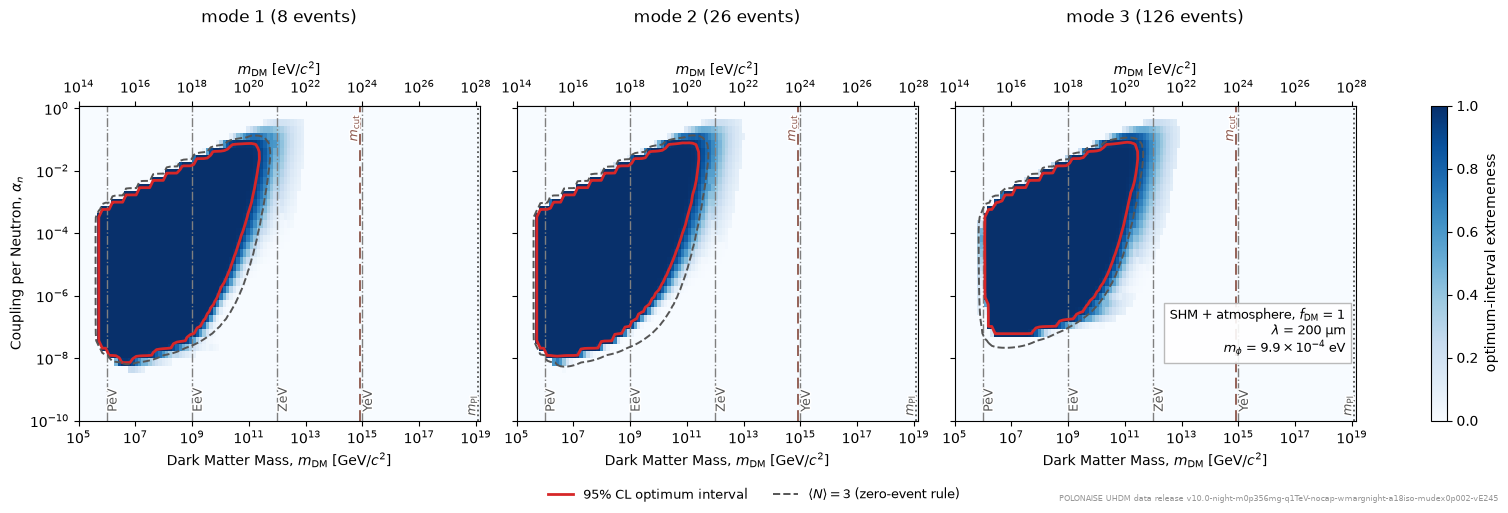

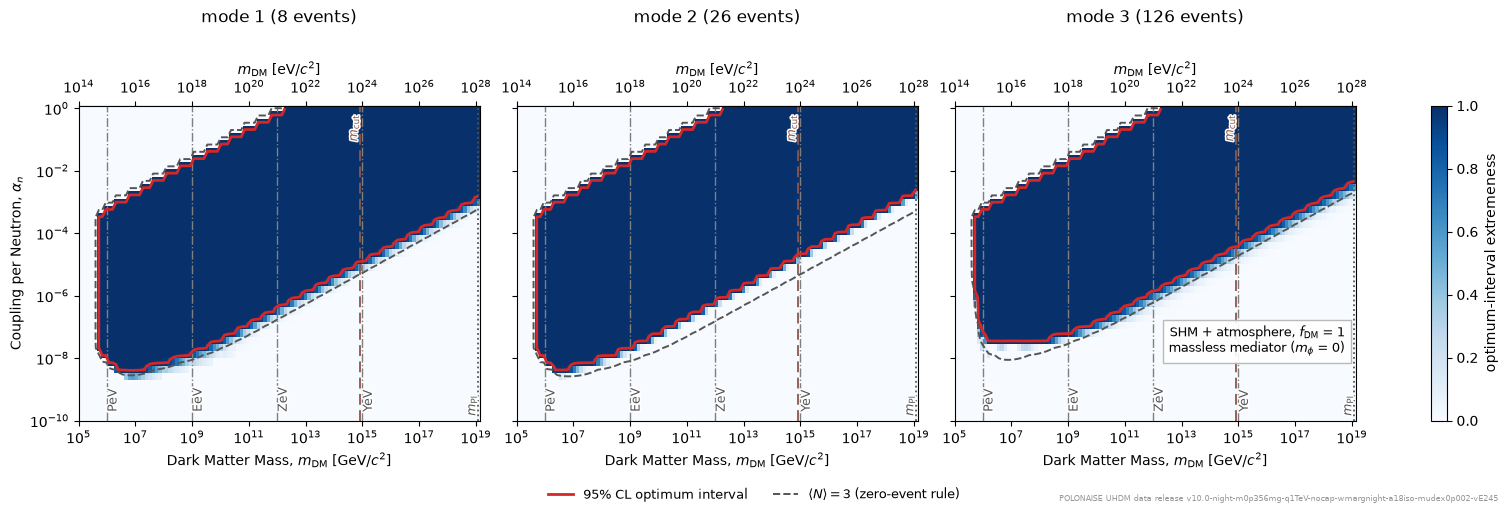

In [4]:
MODES = (1, 2, 3)   # every panel figure below shows all three sensor modes

def excluded_region_panels(tag, fname, info):
    """One panel per mode: extremeness plane, 95% CL and <N> = 3 contours."""
    ms, alphas_n = rel.axes.mass_gev, rel.axes.alpha_n
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True,
                             constrained_layout=True)
    for ax, mode in zip(axes, MODES):
        p = rel.mass_plane("extremeness", mode, tag, f_dm=F_DM)
        mu = rel.mass_plane("mu", mode, tag, f_dm=F_DM)
        mesh = ax.pcolormesh(ms, alphas_n, p, cmap="Blues", vmin=0, vmax=1,
                             shading="auto")
        ax.contour(ms, alphas_n, p, levels=[CONFIDENCE], colors="#d62728",
                   linewidths=2)
        ax.contour(ms, alphas_n, mu, levels=[3.0], colors="#555555",
                   linewidths=1.4, linestyles="--")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
        mark_mass_milestones(ax, ms.min(), M_PLANCK)
        mark_m_cut(ax)
        mark_planck_mass(ax, ms[-1])
        sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                                    lambda x: x / 1e9))
        sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
        ax.set_title(f"mode {mode} ({rel.events(mode).size} events)", pad=28)
    axes[0].set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    fig.colorbar(mesh, ax=axes, label="optimum-interval extremeness")
    # one legend for the whole figure: the two contours mean the same thing
    # in every panel, so proxy lines on the first panel carry the labels
    axes[0].plot([], [], color="#d62728", lw=2,
                 label=f"{CONFIDENCE:.0%} CL optimum interval")
    axes[0].plot([], [], color="#555555", lw=1.4, ls="--",
                 label=r"$\langle N\rangle = 3$ (zero-event rule)")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, fontsize=9, frameon=False)
    # info box once, in the last panel's empty high-mass / low-coupling corner
    axes[2].text(0.975, 0.20, info, transform=axes[2].transAxes,
                 ha="right", va="bottom", fontsize=9,
                 bbox=dict(fc="white", ec="0.7", alpha=0.9))
    save_figure(fig, fname)


excluded_region_panels(
    REF_TAG, "01_excluded_region_200um",
    f"SHM + atmosphere, {F_DM_TXT}\n"
    + lamb_label(LAMB_REF) + "\n"
    + mphi_label(LAMB_REF))
excluded_region_panels(
    "massless", "01_excluded_massless",
    f"SHM + atmosphere, {F_DM_TXT}\n"
    + r"massless mediator ($m_\phi$ = 0)")

## 2. All released ranges

The 95% CL contours for the released finite ranges (2 mm, 200 µm, 20 µm), with
this mode's candidates and atmospheric attenuation everywhere, and the massless
analytic line dashed. The momentum cap
$\tilde q_\text{max} = K_1(\xi)$, $\xi = R_\text{eff}/\lambda$, organizes the
family:

- **Shared floor at long range.** Ranges in the Coulomb regime (mm and above)
  share a common coupling floor; shorter ranges pay the momentum-cap penalty
  and floor out higher — visible here as 20 µm flooring above 200 µm.
- **High-mass endpoints ladder with $\lambda$.** Reach saturates at
  $\sigma_\text{sat} \sim \lambda^2$ while the number density falls as $f_X/m$,
  so each decade of $\lambda$ buys roughly two decades of mass reach; every
  finite-range island closes below the Planck mass.
- **The massless analytic line (black dashed) is the $\lambda\to\infty$ ideal.**
  Its Coulomb reach grows as $\alpha$ without limit and this release does not
  truncate the impact-parameter integral, so the massless contour does not
  close on the right at all: it runs to the Planck mass. The dashed brown line
  is where the halo stops supplying $N_\text{req} = 3$ transits within 10 cm,
  $m_\text{cut} = 8.40\times10^{14}$ GeV, and that — not the surface — is the
  right-hand edge of the claim. The 200 m slice on the same axis is a
  convergence check on the finite-range branch: it lands on the massless
  contour and is not drawn here.
- **The shortest ranges exclude little or nothing.** As $\xi$ grows the
  saturated rate drops below the 95% exclusion bar; in the release's own
  54-point mediator-range sidecar (section 5) the few-µm-and-below channels are
  honest nulls, not plotting gaps. The released cube carries the three finite
  slices above, which bracket that transition.

The floor values and high-mass endpoints are read straight off the figure and the
data release; they are not quoted here because they depend on the mode, its
candidate list, and the fiducials above.

   2mm: m in [5.2e+05, 2.3e+13] GeV, alpha_n down to 4.2e-09
 200um: m in [5.2e+05, 2.1e+11] GeV, alpha_n down to 7.3e-09
  20um: m in [5.2e+05, 2.6e+09] GeV, alpha_n down to 1.8e-07
massless: m in [5.2e+05, 1.2e+19] GeV, alpha_n down to 4.2e-09  (inside m_cut: up to 8.1e+14 GeV)


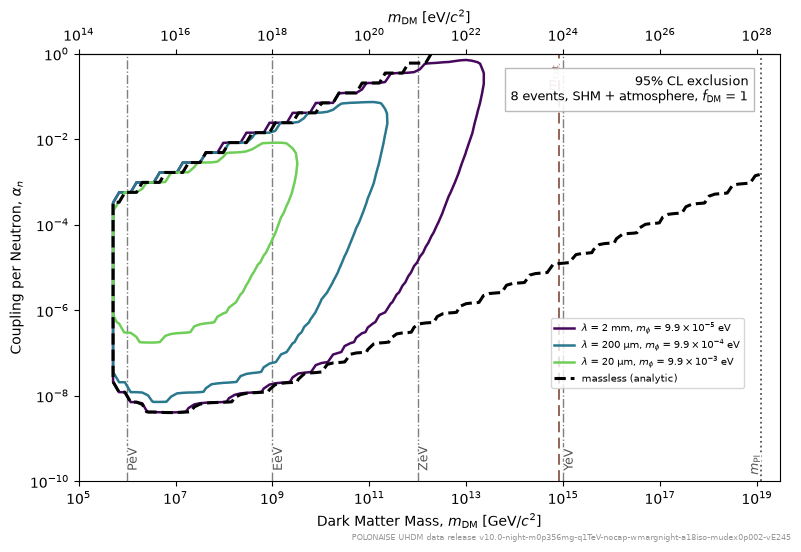

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
CS95 = {}
for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS or tag in HIDE:
        continue
    s = SCANS[tag]
    style = dict(linestyles="--", linewidths=2.2) if lamb is None else \
        dict(linewidths=1.8)
    lab = ("massless (analytic)" if lamb is None
           else range_legend(lamb))
    if (s["extremeness"] >= CONFIDENCE).any():
        CS95[tag] = ax.contour(s["ms"], s["alphas_n"], s["extremeness"],
                               levels=[CONFIDENCE], colors=color, **style)
        ax.plot([], [], color=color, lw=style["linewidths"],
                ls="--" if lamb is None else "-", label=lab)
    else:
        ax.plot([], [], color=color, lw=1.8, label=lab + " (no exclusion)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(REF["ms"].min(), XMAX_MASS)
ax.set_ylim(REF["alphas_n"].min(), 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_mass_milestones(ax, REF["ms"].min(), XMAX_MASS)
mark_m_cut(ax)
mark_planck_mass(ax, REF["ms"][-1])
sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                            lambda x: x / 1e9))
sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
n_shown = len([t for t, _, _ in LAMBDAS if t not in HIDE])
ax.text(0.955, 0.955,
        f"{CONFIDENCE:.0%} CL exclusion\n"
        f"{EVENTS.size} events, SHM + atmosphere, {F_DM_TXT}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="center right", bbox_to_anchor=(0.955, 0.30), fontsize=7)
fig.tight_layout()
save_figure(fig, "01_all_mediator_ranges")

for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    excl = s["extremeness"] >= CONFIDENCE
    if excl.any():
        m_ex = np.broadcast_to(s["ms"], excl.shape)[excl]
        a_ex = np.broadcast_to(s["alphas_n"][:, None], excl.shape)[excl]
        keep = m_ex <= M_CUT
        print(f"{tag:>6}: m in [{m_ex.min():.1e}, {m_ex.max():.1e}] GeV, "
              f"alpha_n down to {a_ex.min():.1e}"
              + ("" if keep.all() else
                 f"  (inside m_cut: up to {m_ex[keep].max():.1e} GeV)"))
    else:
        print(f"{tag:>6}: no exclusion (max p = {s['extremeness'].max():.2f}, "
              f"max mu = {s['counts'].max():.2f})")

## 3. The refined boundary, and the grid it came from

Every contour above is drawn from the cube, and the cube is a grid: the
extremeness is stored on 44 couplings by 119 masses, cells 0.233 dex wide in
$\alpha_n$ and 0.119 dex in mass. Wherever the 95% level falls *inside* a cell
the drawn contour has to guess where — by interpolating in $\log_{10}\alpha_n$
between the two cells that bracket the crossing, the convention
`release/README.md` §5.3 spells out. The release now also ships the crossing
itself, found rather than interpolated:
`release/luhdm_contours_v10_A_f1_atm.json`, one refined (floor, ceiling) polyline
per surface of this file, written by `scripts/refine_contours.py` and
checksummed with the cubes in `release/SHA256SUMS`.

**What refinement is**, in four steps:

- **The same statistic.** It root-finds the 95% crossing of the optimum-interval
  extremeness — the same quantity, computed the same way, with the same
  candidates, efficiency, seed and fiducials, all read back out of the cube being
  refined. It is not a smoothing, a fit, or a second analysis.
- **Bisection between the bracketing cells.** At each mass column the two cells
  that straddle the floor (and the ceiling, where the column has one) start a
  bisection in $\log\alpha_n$ that stops once the edge is pinned to 0.005 dex, a
  fortieth of a cell.
- **Extra mass columns where an edge jumps.** Where neighbouring columns' edges
  differ by more than 0.05 dex the boundary is moving faster than the mass axis
  samples it, so a column is inserted between them and refined the same way,
  recursively, down to 0.01 dex in mass. The massless polyline ends up with 78
  vertices on the cube's own mass columns and 83 inserted between them.
- **The ends traced in mass.** Where an island stops there is no coupling
  crossing left to bisect: the question becomes whether *anything* is excluded at
  a given mass, which is a bisection along the mass axis instead. That is what
  puts the left end of the massless island between two grid columns rather than
  at the first column that happens to be excluded. The massless island has no
  right end to trace — the surface is still excluded at the last mass the cube
  carries — so the sidecar stops the polyline at $m_\text{cut}$ instead and
  records that it did (`m_cut_truncated`, and `cut_at_m_cut` on the right tip).

**Two things not to mistake.** First, every refined vertex is the cube's own
arithmetic: run the refining calculation at a point the cube already carries and
it returns the stored number bit for bit at the file's `float32` storage — the
production run re-checked six such cells per surface and found no difference at
all. Refinement buys resolution, not a different answer. Second, the 95% level is
taken at that same storage precision: extremeness is stored as `float32`, so both
boundaries below test against the level narrowed to what the file can represent,
and a value sitting exactly on 0.95 counts as excluded either way.

**Which of the two is the limit.** The Letter quotes the **refined** boundary —
the massless floor it reports, $3.21\times10^{-9}$ at $5.38\times10^{6}$ GeV, is a
root-found number — while the **grid** is what the released files store: open the
cube and you get grid values, contour them and you get the dashed line below. The
two are the same claim at different resolution, and the gap between them is
bounded by the cell size.

**What moves.** The refined region is a little wider than the grid contour
almost everywhere: the floor drops by up to 0.176 dex (median 0.074) and the
ceiling rises by up to 0.219 dex (median 0.106), both inside one 0.233 dex
coupling cell. The exceptions are two columns where the ceiling comes back 0.006
and 0.003 dex lower rather than higher, which is the interpolation cutting the
corner the other way and is well inside the tolerance the edge is found to.
Both edges move outwards for the same reason — the extremeness saturates towards
1 in the interior of the region, so a straight line drawn between two cells cuts
the corner and lands inside the true edge. The difference is periodic rather than
noisy (the sawtooth in the lower panel): it vanishes wherever the crossing
happens to fall on a grid coupling and peaks when it falls mid-cell. On the left
the change is not a shift but an extension, because a grid contour cannot begin
before the first mass column that is excluded at all: that column is
$5.20\times10^{5}$ GeV, while the island really ends at $4.02\times10^{5}$ GeV,
0.112 dex lower and that much closer to the kinematic wall. Above
$\sim1.5\times10^{12}$ GeV there is no ceiling left to compare — the excluded band
leaves the top of the coupling axis, saturating in the cube and stored as a
`null` ceiling in the sidecar.

refined-contour sidecar release/luhdm_contours_v10_A_f1_atm.json (v10.0-night-m0p356mg-q1TeV-nocap-wmargnight-a18iso-mudex0p002-vE245)
  95% level 0.949999988079071; coupling edges root-found to 0.005 dex, mass columns inserted down to 0.01 dex
  oracle re-evaluated 6 released grid cells per surface: max |d extremeness| = 0 (float32 storage)
  massless_f1: 165 vertices (78 on the cube's mass columns, 83 inserted, 47 open-topped), 2290 oracle calls
       2mm_f1: 275 vertices (65 on the cube's mass columns, 205 inserted, 0 open-topped), 4873 oracle calls
     200um_f1: 224 vertices (48 on the cube's mass columns, 171 inserted, 0 open-topped), 4019 oracle calls
      20um_f1: 136 vertices (32 on the cube's mass columns, 99 inserted, 0 open-topped), 2437 oracle calls


left end: refined tip 4.021e+05 GeV vs first excluded grid column 5.203e+05 GeV (0.112 dex); bracketed in mass between 3.953e+05 GeV (nothing excluded) and 4.021e+05 GeV (still excluded)
right end: the polyline is truncated at m_cut = 8.401e+14 GeV (N_req = 3 transits within 0.1 m); the surface itself is still excluded there, so the cut closes this island, not the surface
deepest floor: refined 3.207e-09 at 5.382e+06 GeV vs grid 3.993e-09 at 8.129e+06 GeV
floor moved down by up to 0.176 dex (median 0.074); ceiling up by up to 0.219 dex (median 0.106); one coupling cell is 0.233 dex


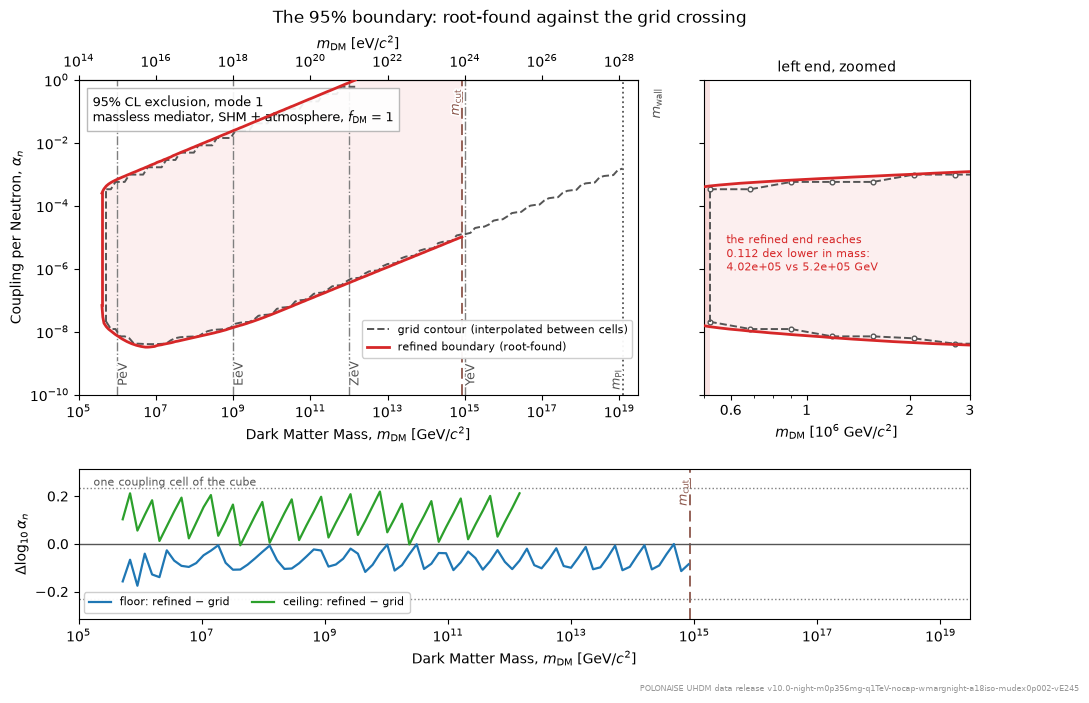

In [6]:
import json

# ---- the refined-contour sidecar: the same crossing, root-found ------------
# The cube samples the extremeness on a coarse (alpha_n x mass) grid, and the
# 95% contours above are that grid's interpolated crossing. The release ships
# the crossing itself as well -- one (floor, ceiling) polyline per surface of
# file A, root-found on the same statistic by scripts/refine_contours.py and
# checksummed in release/SHA256SUMS with the cubes. Nothing here recomputes any
# physics: the sidecar is read, not remade.
CONTOURS = Path("../release/luhdm_contours_v10_A_f1_atm.json")

# The 95% level at the release's storage-precision convention: the cube stores
# extremeness as float32, so the level is narrowed before comparing and a value
# sitting exactly on 0.95 still counts as excluded. The refinement root-finds
# that same narrowed level, so the two boundaries below are the same test.
LEVEL = float(np.float32(CONFIDENCE))

REFINED = None
if not CONTOURS.exists():
    print(f"SKIPPED: no refined-contour sidecar at release/{CONTOURS.name}")
else:
    DOC = json.loads(CONTOURS.read_text())
    PROV_C = DOC["provenance"]
    # Which cube was refined, and in which scheme: both are read off the
    # sidecar's own provenance record rather than trusted, so a file refined
    # against another cube cannot be drawn on top of contours from this one.
    assert DOC["format"] == "luhdm-refined-contours", "not a refined-contour file"
    assert DOC["confidence"] == CONFIDENCE, "the sidecar is a different level"
    assert Path(PROV_C["cube_path"]).name == rel.path.name, \
        "the sidecar refines a different released cube"
    assert PROV_C["cube_version_tag"] == rel.version_tag, \
        "the sidecar refines a different version of the cube"
    assert PROV_C["q_thresh_gev"] == float(Q_THRESH), \
        "the sidecar was refined in a different analysis window"
    assert PROV_C["b_constrained_max_m"] is None, \
        "the sidecar caps the impact-parameter integral; the release does not"
    _sums = dict(ln.split()[::-1] for ln in
                 (CONTOURS.parent / "SHA256SUMS").read_text().splitlines()
                 if len(ln.split()) == 2)
    assert CONTOURS.name in _sums, "the sidecar is not checksummed in SHA256SUMS"
    assert _sums[rel.path.name] == PROV_C["cube_sha256"], \
        "the sidecar names a cube checksum the release does not record"
    # The cube it names is the file this notebook opened, so that cube's tag is
    # the sidecar's version too, and it stamps the figure below.
    CONT_TAG = PROV_C["cube_version_tag"]
    REFINED = DOC["surfaces"]["massless_f1"]

    print(f"refined-contour sidecar release/{CONTOURS.name} ({CONT_TAG})")
    print(f"  95% level {LEVEL!r}; coupling edges root-found to "
          f"{PROV_C['tolerances']['tol_alpha_dex']:g} dex, mass columns "
          f"inserted down to {PROV_C['tolerances']['mass_res_dex']:g} dex")
    print(f"  oracle re-evaluated {PROV_C['spot_n_cells']} released grid cells "
          f"per surface: max |d extremeness| = "
          f"{max(PROV_C['spot_max_dp'].values()):g} (float32 storage)")
    for _tag, _s in DOC["surfaces"].items():
        print(f"  {_tag:>11}: {len(_s['mass_gev']):3d} vertices "
              f"({_s['n_grid_columns']} on the cube's mass columns, "
              f"{_s['n_inserted']} inserted, "
              f"{_s['n_open_top_columns']} open-topped), "
              f"{_s['n_oracle_calls']} oracle calls")


def refined_vs_grid(surf, tag, figname):
    """The refined boundary over the grid-interpolated one, for one surface."""
    ms, alphas_n = rel.axes.mass_gev, rel.axes.alpha_n
    # the grid boundary: the release's own convention (README section 5.3), the
    # level crossing interpolated in log10(alpha_n) between bracketing cells
    lo = np.full(ms.size, np.nan)
    hi = np.full(ms.size, np.nan)
    for i, m in enumerate(ms):
        lo[i], hi[i] = rel.excluded_alpha_band(m, tag, mode=MODE_NUMBER,
                                               f_dm=F_DM, confidence=CONFIDENCE)
    # a ceiling that saturates at the top of the coupling axis is not a
    # crossing: those columns are open-topped and have nothing to refine
    hi = np.where(hi >= alphas_n[-1], np.nan, hi)

    rm = np.asarray(surf["mass_gev"], dtype=float)
    rf = np.asarray(surf["floor_alpha_n"], dtype=float)
    rc = np.asarray([np.nan if c is None else c
                     for c in surf["ceiling_alpha_n"]], dtype=float)
    cell_dex = surf["cell_dex"]          # one coupling cell of the cube

    # the two boundaries on the same mass columns, for the difference panel:
    # the refined polyline read at each grid column, in decades of coupling
    lg = np.log10
    # only where the refined polyline actually reaches: it is truncated at
    # m_cut, and np.interp beyond its last vertex holds that vertex flat, which
    # would read as a difference rather than as the absence of one. The ceiling
    # comparison below already restricts itself the same way.
    on_grid = np.isfinite(lo) & (ms <= rm.max())
    d_floor = np.interp(lg(ms[on_grid]), lg(rm), lg(rf)) - lg(lo[on_grid])
    fin = np.isfinite(rc)
    on_ceil = np.isfinite(hi) & (ms <= rm[fin].max())
    d_ceil = np.interp(lg(ms[on_ceil]), lg(rm[fin]), lg(rc[fin])) - lg(hi[on_ceil])

    fig = plt.figure(figsize=(11.5, 7.0))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.1, 1.0], width_ratios=[2.1, 1.0],
                          hspace=0.32, wspace=0.16)
    ax = fig.add_subplot(gs[0, 0])
    axz = fig.add_subplot(gs[0, 1])
    axd = fig.add_subplot(gs[1, :])

    i0 = int(np.argmax(on_grid))          # first mass column with an exclusion
    for a, zoom in ((ax, False), (axz, True)):
        a.fill_between(rm, rf, np.where(np.isfinite(rc), rc, alphas_n[-1]),
                       color="#d62728", alpha=0.07, lw=0, zorder=0)
        a.plot(ms, lo, color="#555555", lw=1.4, ls="--", zorder=3,
               marker="o" if zoom else None, ms=3.4, mfc="white")
        a.plot(ms, hi, color="#555555", lw=1.4, ls="--", zorder=3,
               marker="o" if zoom else None, ms=3.4, mfc="white")
        # each boundary closes on the left at its own left end: the grid one
        # can only start at a mass column, the refined one at the island tip
        a.plot([ms[i0]] * 2, [lo[i0], hi[i0]], color="#555555", lw=1.4,
               ls="--", zorder=3)
        a.plot(rm, rf, color="#d62728", lw=2.0, zorder=4)
        a.plot(rm, rc, color="#d62728", lw=2.0, zorder=4)
        a.plot([rm[0]] * 2, [rf[0], rc[0]], color="#d62728", lw=2.0, zorder=4)
        a.set_xscale("log")
        a.set_yscale("log")
        a.set_ylim(alphas_n.min(), 1.0)
        a.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
    ax.set_xlim(ms.min(), XMAX_MASS)
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    mark_mass_milestones(ax, ms.min(), XMAX_MASS)
    mark_m_cut(ax)
    mark_planck_mass(ax, ms[-1])
    sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                                lambda x: x / 1e9))
    sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
    ax.plot([], [], color="#555555", lw=1.4, ls="--",
            label="grid contour (interpolated between cells)")
    ax.plot([], [], color="#d62728", lw=2.0,
            label="refined boundary (root-found)")
    # kept clear of the m_Pl label, which sits along the bottom spine
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 0.10), fontsize=8,
              framealpha=0.95)
    ax.text(0.025, 0.955,
            f"{CONFIDENCE:.0%} CL exclusion, mode {MODE_NUMBER}\n"
            f"massless mediator, SHM + atmosphere, {F_DM_TXT}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(fc="white", ec="0.7", alpha=0.9))

    # the zoom: the left end, where the grid boundary can only start at a mass
    # column and the refined one is carried down to the island tip
    axz.set_xlim(5.0e5, 3.0e6)
    axz.set_xticks([6e5, 1e6, 2e6, 3e6])
    axz.set_xticklabels(["0.6", "1", "2", "3"])
    axz.set_xlabel(r"$m_{\rm DM}$ [$10^{6}$ GeV/$c^2$]")
    axz.axvspan(rm[0], ms[i0], color="#d62728", alpha=0.13, lw=0, zorder=0.5)
    axz.axvline(M_WALL, color="#555555", lw=1.3, ls=":", zorder=1)
    axz.text(M_WALL, 0.985, r"$m_{\mathrm{wall}}$ ", color="#555555", fontsize=9,
             ha="right", va="top", rotation=90, zorder=1.5,
             transform=axz.get_xaxis_transform())
    axz.text(ms[i0] * 1.12, 3e-6,
             f"the refined end reaches\n{np.log10(ms[i0] / rm[0]):.3f} dex lower "
             f"in mass:\n{rm[0]:.3g} vs {ms[i0]:.3g} GeV",
             color="#d62728", fontsize=8, ha="left", va="center")
    axz.set_title("left end, zoomed", fontsize=10, pad=6)
    axz.tick_params(labelleft=False)

    # the difference: refined minus grid, in decades of coupling
    axd.axhline(0.0, color="#555555", lw=1.0)
    for s in (+1, -1):
        axd.axhline(s * cell_dex, color="#7f7f7f", lw=1.0, ls=":")
    axd.text(ms.min() * 1.5, cell_dex, " one coupling cell of the cube",
             color="#555555", fontsize=8, ha="left", va="bottom")
    axd.plot(ms[on_grid], d_floor, color="#1f77b4", lw=1.6,
             label="floor: refined $-$ grid")
    axd.plot(ms[on_ceil], d_ceil, color="#2ca02c", lw=1.6,
             label="ceiling: refined $-$ grid")
    axd.set_xscale("log")
    axd.set_xlim(ms.min(), XMAX_MASS)
    axd.set_ylim(-1.35 * cell_dex, 1.35 * cell_dex)
    axd.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
    axd.set_ylabel(r"$\Delta \log_{10}\alpha_n$")
    axd.legend(loc="lower left", fontsize=8, ncols=2, framealpha=0.95)
    mark_m_cut(axd, y=0.96)

    fig.suptitle("The 95% boundary: root-found against the grid crossing",
                 fontsize=12)
    save_figure(fig, figname, stamp=CONT_TAG, bbox_inches="tight")

    # what the refinement moved, in numbers
    _left, _right = surf["tips"]["left"], surf["tips"]["right"]
    print(f"left end: refined tip {rm[0]:.3e} GeV vs first excluded grid column "
          f"{ms[i0]:.3e} GeV ({np.log10(ms[i0] / rm[0]):.3f} dex); bracketed in "
          f"mass between {_left['m_not_excluded']:.3e} GeV (nothing excluded) "
          f"and {_left['m_excluded']:.3e} GeV (still excluded)")
    if _right.get("cut_at_m_cut"):
        print(f"right end: the polyline is truncated at m_cut = "
              f"{_right['m_cut_gev']:.3e} GeV (N_req = {_right['n_req']:g} "
              f"transits within {_right['b_cap_m']:g} m); the surface itself is "
              "still excluded there, so the cut closes this island, not the "
              "surface")
    elif _right.get("open_at_mass_axis_edge"):
        print("right end: still excluded at the last mass the cube carries, so "
              "there is no tip to trace -- m_cut closes this island, not the "
              "surface")
    print(f"deepest floor: refined {rf.min():.3e} at "
          f"{rm[int(np.argmin(rf))]:.3e} GeV vs grid {np.nanmin(lo):.3e} at "
          f"{ms[int(np.nanargmin(lo))]:.3e} GeV")
    print(f"floor moved down by up to {-d_floor.min():.3f} dex "
          f"(median {-np.median(d_floor):.3f}); ceiling up by up to "
          f"{d_ceil.max():.3f} dex (median {np.median(d_ceil):.3f}); "
          f"one coupling cell is {cell_dex:.3f} dex")


if REFINED is not None:
    refined_vs_grid(REFINED, "massless", "01_refined_vs_grid")

### Reproducing the refined boundary

Everything above reads the sidecar. This subsection says where its numbers came
from, and then remakes a few of them here.

Three commands stand between the candidate lists and the polylines drawn above:
the scan campaign that filled the cube one mediator slice at a time, the
assembly step that wrote file A out of those shards, and the refinement that
root-found the boundary on the assembled cube. None of the three is typed out
here. Each is recorded inside the released files, and the cell below prints them
back out, so what appears is what ran.

The campaign line is reconstructed from the `build_release.py` command each
shard stored, mapped back onto the environment knobs
`scripts/release_campaign_driver.sh` reads. Two of them carry the conventions
this notebook keeps repeating: an absent `--b-constrained-max` is `BCAP=none`,
the uncapped impact-parameter integral, and `--n-mc-hi` is the second Monte
Carlo tier the cells near the boundary are re-evaluated on.

In [7]:
# The production commands, read out of the released provenance rather than
# typed in here. Three records are involved: the per-shard build_release.py
# calls and the assemble_release.py call in release/provenance_<cube>.json,
# and the refine_contours.py call in each contour sidecar.
RELEASE_DIR = CONTOURS.parent
# The release version this notebook is reading, taken off the cube's own
# file name, so the records printed below are this release's and not those
# of any superseded file that happens to still be sitting in release/.
REL_VERSION = rel.path.stem.split("_")[2]          # ..._datarelease_v10_A_...

# driver knob -> the build_release flag it sets. An absent --b-constrained-max
# is not a missing knob: it is BCAP=none, the uncapped cross section.
KNOB_FLAG = {"BCAP": "--b-constrained-max", "LSET": "--lambda-set",
             "MTIER": "--m-tier", "NA": "--n-a", "NMC_HI": "--n-mc-hi",
             "KNL": "--projection-kernel", "WORKERS": "--workers"}


def driver_env(argv):
    """The campaign driver's env knobs behind one recorded build_release argv."""
    out = []
    for knob, flag in KNOB_FLAG.items():
        if flag in argv:
            out.append(f"{knob}={argv[argv.index(flag) + 1]}")
        elif knob == "BCAP":
            out.append("BCAP=none")
    return " ".join(out)


PROV_BUILD = json.loads(
    (RELEASE_DIR / f"provenance_{rel.path.stem}.json").read_text())

print("1. the scan campaign -- one build_release.py per mediator shard, "
      "driven by scripts/release_campaign_driver.sh:")
for _pass, _records in PROV_BUILD["run_config"].items():
    for _env in sorted({driver_env(_r["argv"]) for _r in _records}):
        print(f"   PASSES={_pass} {_env} \\")
        print(f"       bash scripts/release_campaign_driver.sh"
              f"        # {len(_records)} shard(s)")

print("\n2. the assembly -- shards to cube, run once per hypothesis:")
for _pf in sorted(RELEASE_DIR.glob(
        f"provenance_luhdm_datarelease_{REL_VERSION}_*.json")):
    print(f"   {json.loads(_pf.read_text())['assembly']['argv']}")

print("\n3. the refinement -- root-finding the boundary on the assembled cube:")
for _cf in sorted(RELEASE_DIR.glob(f"luhdm_contours_{REL_VERSION}_*.json")):
    print("   " + " ".join(json.loads(_cf.read_text())["provenance"]["argv"]))

print(f"\nthe fidelity the cube was built at: {rel.attrs['fid_json']}")
print(f"  two-tier Monte Carlo: a cell whose base extremeness lands in "
      f"[{float(rel.attrs['fid_p_hi_lo']):g}, 1) -- the band the 95% boundary "
      f"lives in -- is re-evaluated")
print(f"  on a second table of {int(rel.attrs['fid_n_mc_hi']):,} trials "
      f"instead of the bulk {int(rel.attrs['fid_n_mc']):,}.")

1. the scan campaign -- one build_release.py per mediator shard, driven by scripts/release_campaign_driver.sh:
   PASSES=atm BCAP=none LSET=v7quick MTIER=119 NA=44 NMC_HI=100000 KNL=isotropic-folded WORKERS=75 \
       bash scripts/release_campaign_driver.sh        # 5 shard(s)
   PASSES=noatm BCAP=none LSET=v7quick MTIER=119 NA=44 NMC_HI=100000 KNL=isotropic-folded WORKERS=75 \
       bash scripts/release_campaign_driver.sh        # 5 shard(s)
   PASSES=halo BCAP=none LSET=v7quick MTIER=119 NA=44 KNL=isotropic-folded WORKERS=16 \
       bash scripts/release_campaign_driver.sh        # 3 shard(s)

2. the assembly -- shards to cube, run once per hypothesis:
   scripts/assemble_release.py --atm-dir ~/code/uhdm/release_shards_v10/atm --noatm-dir ~/code/uhdm/release_shards_v10/noatm --halo-dir ~/code/uhdm/release_shards_v10/halo --out release/luhdm_datarelease_v10_A_f1_atm.h5 --version-tag v10.0-night-m0p356mg-q1TeV-nocap-wmargnight-a18iso-mudex0p002-vE245 --select f1-atm
   scripts/assemb

Now the same code, run here rather than quoted. The refiner is called on
**file B**, the $f_\mathrm{DM}$ = 0.1 bare-halo cube, at three of its massless
surface's mass columns. File B is the cheap one: with the atmosphere off there
is no attenuation ODE to integrate, so a few columns take tens of seconds where
the released run took hours over all of them.

Nothing below reimplements anything. `scripts/refine_contours.py` is run as a
subprocess, the same file the production command above named, with the work
restricted to those columns (`--columns`, which also turns off the tip tracing)
and with inserted columns suppressed (`--no-insert`), so what comes back lines
up vertex-for-vertex with the released polyline's grid columns. `--spot 2` makes
the refiner recompute two of the cube's own cells before it starts and compare
them against the stored `float32`; it says so in its output either way. The
floors it returns are then checked against the released sidecar at the
refinement's own coupling tolerance.

In [8]:
import os
import subprocess
import sys
import tempfile

REPO = Path.cwd().parent            # notebooks/ -> repo root
DEMO_CUBE = REPO / "release" / "luhdm_datarelease_v10_B_f0p1_noatm.h5"
DEMO_CONTOURS = REPO / "release" / "luhdm_contours_v10_B_f0p1_noatm.json"
DEMO_SURFACE = "massless_f0p1_noatm"


def demo_columns(surf, n=3):
    """n of a released surface's own mass columns, spread across its span."""
    grid = [im for im, org in zip(surf["coarse_im"], surf["origin"])
            if org == "grid"]
    return [grid[int(round(q * (len(grid) - 1)))]
            for q in np.linspace(0.2, 0.8, n)]


if not (DEMO_CUBE.exists() and DEMO_CONTOURS.exists()):
    print(f"SKIPPED: the demo needs release/{DEMO_CUBE.name} and "
          f"release/{DEMO_CONTOURS.name}")
else:
    DOC_B = json.loads(DEMO_CONTOURS.read_text())
    SURF_B = DOC_B["surfaces"][DEMO_SURFACE]
    DEMO_OUT = Path(tempfile.mkdtemp(prefix="luhdm_demo_")) / "contours.json"
    DEMO_CMD = [sys.executable, "scripts/refine_contours.py",
                "--release", f"release/{DEMO_CUBE.name}",
                "--surfaces", DEMO_SURFACE,
                "--mode", str(SURF_B["mode"]),
                "--columns", ",".join(str(c) for c in demo_columns(SURF_B)),
                "--spot", "2", "--workers", "2",
                "--no-insert", "--no-tips",
                "--out", str(DEMO_OUT)]
    print("$ " + " ".join(DEMO_CMD[1:]))
    # The refiner is a separate process, so the halo frame has to be handed
    # over the process boundary: config.set_v_earth_km_s above only moved it
    # in this kernel. LUHDM_V_EARTH is the knob refine_contours.py checks
    # against the cube's own v_earth_km_s attribute before it refines
    # anything, and it refuses to run if the two disagree.
    DEMO_ENV = {**os.environ,
                "LUHDM_V_EARTH": f"{release.open_release(DEMO_CUBE).v_earth_km_s:g}"}
    _t0 = time.time()
    _proc = subprocess.run(DEMO_CMD, cwd=REPO, capture_output=True, text=True,
                           env=DEMO_ENV)
    print((_proc.stdout or _proc.stderr).rstrip())
    assert _proc.returncode == 0, f"the refiner exited {_proc.returncode}"

    DEMO = json.loads(DEMO_OUT.read_text())["surfaces"][DEMO_SURFACE]
    TOL_ALPHA = DOC_B["provenance"]["tolerances"]["tol_alpha_dex"]
    print(f"\nrefined here in {time.time() - _t0:.0f} s, against the released "
          f"sidecar release/{DEMO_CONTOURS.name}:")
    print(f"{'column':>7} {'m_DM [GeV]':>13} {'released floor':>17} "
          f"{'this run':>15} {'|difference| [dex]':>20}")
    WORST = 0.0
    for _im, _m, _a in zip(DEMO["coarse_im"], DEMO["mass_gev"],
                           DEMO["floor_alpha_n"]):
        _j = SURF_B["coarse_im"].index(_im)
        _released = SURF_B["floor_alpha_n"][_j]
        _d = abs(np.log10(_a / _released))
        WORST = max(WORST, _d)
        print(f"{_im:>7} {_m:>13.4e} {_released:>17.6e} {_a:>15.6e} "
              f"{_d:>20.2e}")
    print(f"\nworst disagreement {WORST:.2e} dex, against the refinement's own "
          f"coupling tolerance of {TOL_ALPHA:g} dex")
    assert WORST <= TOL_ALPHA, \
        "the live refinement does not reproduce the released boundary"

$ scripts/refine_contours.py --release release/luhdm_datarelease_v10_B_f0p1_noatm.h5 --surfaces massless_f0p1_noatm --mode 1 --columns 20,40,60 --spot 2 --workers 2 --no-insert --no-tips --out /tmp/luhdm_demo_q4y9b8sw/contours.json


oracle timeout: 6000 s;  mu_dex: 0.002 dex
halo frame: v_earth = 245 km/s (lab frame; v_max = 789.0 km/s)
release: release/luhdm_datarelease_v10_B_f0p1_noatm.h5 (v10.0-night-m0p356mg-q1TeV-nocap-wmargnight-a18iso-mudex0p002-vE245-mc2tier6)  b_cap=None  kernel=isotropic-folded  FID={'n_ode': 400, 'n_shm': 300000, 'n_q': 240, 'q_span': 30000.0, 'n_mc': 10000, 'mu_cap': 85.0, 'n_mc_hi': 1000000, 'p_hi_lo': 0.9, 'mu_dex': 0.002, 'v_earth_km_s': 245.0}
mode 1, level 0.95, tol_alpha 0.005 dex, tol_wall 0.05 dex, mass_res 0.01 dex, workers 2
[surface massless_f0p1_noatm] lambda=massless (inf m), f_dm=0.1, atmosphere=False, F_SCALE=1, q_endpoint_factor=1
    spot im= 40 ia=12 p_cube=0.477400 p_oracle=0.477400  OK (bit-exact in the cube's float32)
    spot im= 60 ia=17 p_cube=0.342700 p_oracle=0.342700  OK (bit-exact in the cube's float32)
  [massless_f0p1_noatm] 3 excluded cube columns (3 open-topped: no ceiling) (restricted to [20, 40, 60])
  [massless_f0p1_noatm] 3 vertices, 18 oracle calls 

**Why any of this is reproducible.** The extremeness at a grid point is a Monte
Carlo quantity, so a rerun has every excuse to come back a little different. It
does not, and the reason is that the calibration tables are pinned rather than
drawn fresh: `build_release.PerMuTable` rounds the expected count $\mu$ onto a
0.02-dex grid and builds one seeded optimum-interval table per rounded value,
from the single seed the cube records in `attrs['seed']`. The extremeness is
then a pure function of the coupling, the mass and the surface, so the refiner
asking for a cell the build already computed gets the same bits back — which is
what the spot checks above are testing, and why they land on the stored
`float32` exactly rather than within some Monte Carlo tolerance. The two-tier
rule belongs to that function rather than overriding it: a cell whose base
extremeness falls in the boundary band is re-evaluated on a second table, seeded
one step off the first, deterministically and at the same cells every run. It
buys resolution where the boundary is and costs nothing in reproducibility —
run the command in the cell above against the same released files and it prints
the same floors, to the last digit.

## 4. The three sensor modes

The same stored surfaces, all three modes at once, so the modes can be compared
without flipping between figures. Nothing here is recomputed — every contour is
a level set of file A's extremeness surface, at $f_\mathrm{DM}$ = 1 with
atmospheric attenuation applied.

**Why the modes differ at all.** The three sensors watch the same halo, so the
spread between their contours is candidate count and detection efficiency and
nothing else. The window edge is a stated momentum threshold and is not placed
by the efficiency curves, so each mode meets it wherever its own turn-on
happens to be: modes 1 and 2 reach half efficiency within a few tens of percent
of the edge — mode 2 just below it, mode 1 just above — while mode 3 turns on
several TeV higher, so its softest in-window candidate sits far out on the toe
of its curve and it pays by far the largest efficiency price. The summary cell
below prints all three turn-on points against the edge. Which mode ends up with
the deepest coupling floor is the outcome of that balance against the candidate
counts, and it has changed as the efficiency treatment changed, so it is not
asserted here in prose: the same cell reads the ordering off the cube.

### What the cube carries

Before any figure: how much of each (mode, range) surface is excluded, and
whether any cell failed. The excluded fraction is the share of the whole
(mass, coupling) grid above the 95% CL level, counted over the entire grid
rather than over the physical mass window, so it is a completeness diagnostic
and not a physics number. The `status` flag records how each cell was obtained,
and only code 1 is a failure — the cell raised, and its extremeness is stored as
`NaN`. The other non-zero codes are deterministic shortcuts, cells where the
answer is known without running the Monte Carlo, and they are the majority of
any cube. The bracket therefore counts failures, not shortcuts.

In [9]:
N_CELLS = rel.axes.alpha_n.size * rel.axes.mass_gev.size
print(f"{'range':>9} | " + "  ".join(f"mode {n}" for n in ALL_MODES)
      + "     (excluded fraction of the grid; [undefined cells of "
      + f"{len(ALL_MODES) * N_CELLS}])")
print("-" * 76)
for tag in RANGES:
    cells, bad = [], 0
    for n in ALL_MODES:
        d = load(n, tag)
        cells.append(f" {(d['extremeness'] >= CONFIDENCE).mean():.3f} ")
        bad += int((rel.mass_plane("status", mode=n, lam=LAM_M[tag],
                                   f_dm=F_DM) == 1).sum())
    print(f"{LABEL[tag]:>9} | " + " ".join(cells) + f"   [{bad}]")

    range | mode 1  mode 2  mode 3     (excluded fraction of the grid; [undefined cells of 15708])
----------------------------------------------------------------------------
 massless |  0.498   0.483   0.442    [0]
     2 mm |  0.282   0.278   0.257    [0]
   200 µm |  0.187   0.186   0.163    [0]
    20 µm |  0.087   0.086   0.062    [75]


### The three modes on one plane, massless mediator

The reference view: each mode's 95% CL excluded region for a massless mediator
($\lambda \to \infty$), all on the same axes. One range means there is no shade
to read here, so each contour is drawn in its mode's own hue.

The region is bounded on the left by the kinematic wall, below by the statistics
floor, above by the atmospheric ceiling, and on the right by the halo flux cut
$m_\mathrm{cut}$ — the dashed brown line, which is drawn rather than applied, and
which assumes three expected transits within 10 cm during the exposure. Contours
continue past it because the stored surfaces do; they should not be read as
limits there. All four edges are taken apart in
[`03_the_edges.ipynb`](03_the_edges.ipynb).

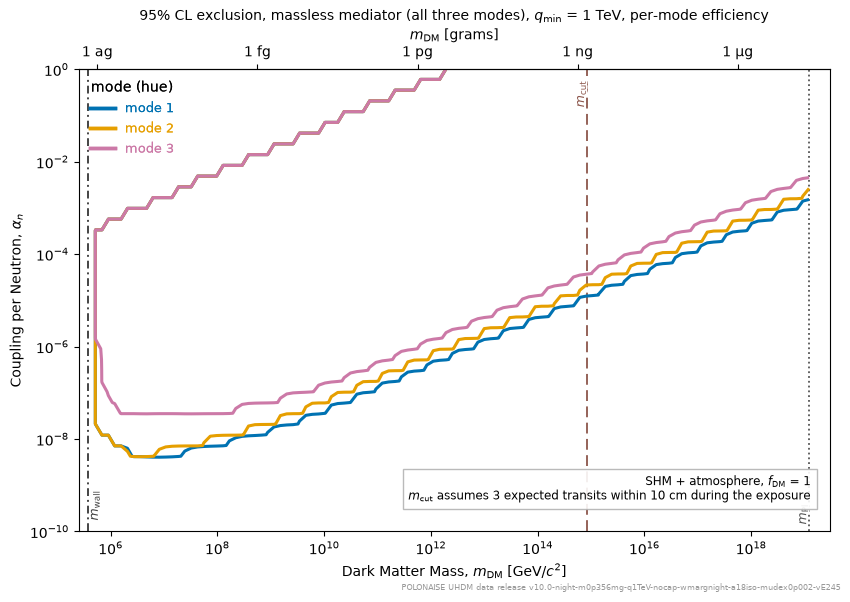

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 6))
for mode in PLOT_MODES:
    d = load(mode, "massless")
    if not (d["extremeness"] >= CONFIDENCE).any():
        continue
    ax.contour(d["ms"], d["alphas_n"], d["extremeness"], levels=[CONFIDENCE],
               colors=[BASE[mode]], linestyles=[STYLE["massless"]],
               linewidths=2.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(XMIN_MASS, XMAX_MASS)
ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_wall(ax)
mark_m_cut(ax)
mark_planck_mass(ax, rel.axes.mass_gev[-1])
add_gram_axis(ax, XMIN_MASS, XMAX_MASS)
ttl = ("mode " + "/".join(map(str, PLOT_MODES)) if len(PLOT_MODES) < 3
       else "all three modes")
ax.set_title(f"95% CL exclusion, massless mediator ({ttl}), "
             f"{Q_MIN_TXT}, per-mode efficiency", fontsize=10)

# The mode key is written straight onto the plot -- frameless, in the empty
# upper-left, each entry in that mode's own colour -- so the hue is read off the
# words themselves and not off a small swatch.
leg = ax.legend(handles=[Line2D([], [], color=BASE[m], lw=2.5, label=f"mode {m}")
                         for m in PLOT_MODES],
                loc="upper left", frameon=False, fontsize=9, title="mode (hue)")
for _t, _m in zip(leg.get_texts(), PLOT_MODES):
    _t.set_color(BASE[_m])
ax.add_artist(leg)

# the flux cut is an assumption, so it says so wherever it is drawn
ax.text(0.975, 0.06, f"SHM + atmosphere, {F_DM_TXT}\n"
        + r"$m_{\mathrm{cut}}$ " + CUT_TXT.replace("\n", " "),
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
fig.tight_layout()
save_figure(fig, "04_exclusion_modes" + "".join(map(str, PLOT_MODES)))
plt.show()

### Per-mode summary: candidates, efficiency, and where each mode floors out

Three numbers separate the modes, and the cell below prints all three straight
from the cube: how many of a mode's candidates fall inside the analysis window,
where its efficiency turns on relative to the window edge, and the lowest
coupling it excludes together with the mass at which it first gets there.

The last of those is the mode ordering. The cell reads it off the cube and names
whichever mode reaches the deepest floor, rather than repeating a number in
prose — the ordering is a close race between the candidate counts and the
efficiency penalties, and the efficiency treatment can re-deal it. A floor is
the lowest coupling *row of the stored grid* that has any excluded cell, so two
modes whose true floors differ by less than one grid step land on the same row;
the cell says so when that happens rather than picking a winner.

Floors are quoted **inside the mass window only**: below the kinematic wall
nothing is excluded, and to the right of the flux cut the surfaces describe a
flux the halo does not deliver, so only the cells between the two are counted.

In [11]:
MS, AL = rel.axes.mass_gev, rel.axes.alpha_n
WINDOW = (MS >= M_WALL) & (MS <= M_CUT)

print(f"analysis window q_min = {Q_THRESH:.0f} GeV;  mass window "
      f"{M_WALL:.3g} .. {M_CUT:.3g} GeV")
print(f"  (the upper end assumes {N_REQ:g} expected transits within "
      f"{B_CAP * 100:.0f} cm during the exposure -- an assumption)\n")

print(f"{'mode':>5} {'cands':>6} {'in window':>10} {'softest in [GeV]':>17} "
      f"{'eff. there':>11} {'50% eff. at':>12} {'eff. at q_min':>14}")
for m in ALL_MODES:
    ev = np.sort(rel.events(m))
    q, e = rel.efficiency_curve(m)
    inw = ev[ev >= Q_THRESH]
    print(f"{m:>5} {ev.size:>6} {inw.size:>10} {inw.min():>17.0f} "
          f"{float(np.interp(inw.min(), q, e)):>11.2e} "
          f"{float(np.interp(0.5, e, q)):>12.0f} "
          f"{float(np.interp(Q_THRESH, q, e)):>14.3f}")

print("\nlowest excluded coupling inside the mass window, per mode and range:")
floors = {}
for tag in RANGES:
    for m in ALL_MODES:
        excl = (rel.mass_plane("extremeness", m, LAM_M[tag], f_dm=F_DM)
                >= CONFIDENCE) & WINDOW[None, :]
        if not excl.any():
            print(f"  {LABEL[tag]:>9}  mode {m}: nothing excluded")
            continue
        ia = int(np.where(excl.any(axis=1))[0][0])
        m_floor = MS[excl[ia]]
        m_all = MS[excl.any(axis=0)]
        floors[(tag, m)] = float(AL[ia])
        print(f"  {LABEL[tag]:>9}  mode {m}: floor alpha_n = {AL[ia]:.2e} "
              f"(first reached at m = {m_floor.min():.1e} GeV); "
              f"excluded masses {m_all.min():.1e} .. {m_all.max():.1e} GeV")

deep = {m: floors[("massless", m)] for m in ALL_MODES if ("massless", m) in floors}
if deep:
    lo = min(deep.values())
    best = [m for m, v in deep.items() if v == lo]
    tie = "" if len(best) == 1 else "  (a tie on the coupling grid)"
    print(f"\ndeepest floor on the massless plane: alpha_n = {lo:.2e}, set by "
          f"mode {' and '.join(map(str, best))}{tie}")
    print("  per mode: " + ",  ".join(f"mode {m}: {v:.2e}"
                                      for m, v in sorted(deep.items())))

analysis window q_min = 1000 GeV;  mass window 3.8e+05 .. 8.4e+14 GeV
  (the upper end assumes 3 expected transits within 10 cm during the exposure -- an assumption)

 mode  cands  in window  softest in [GeV]  eff. there  50% eff. at  eff. at q_min
    1      8          8              1521    8.57e-01         1209          0.173
    2     26         24              1015    6.16e-01          948          0.592
    3    126        126              1569    2.46e-03         5541          0.000

lowest excluded coupling inside the mass window, per mode and range:
   massless  mode 1: floor alpha_n = 4.25e-09 (first reached at m = 2.7e+06 GeV); excluded masses 5.2e+05 .. 8.1e+14 GeV
   massless  mode 2: floor alpha_n = 4.25e-09 (first reached at m = 2.7e+06 GeV); excluded masses 5.2e+05 .. 8.1e+14 GeV
   massless  mode 3: floor alpha_n = 3.62e-08 (first reached at m = 1.6e+06 GeV); excluded masses 5.2e+05 .. 8.1e+14 GeV
       2 mm  mode 1: floor alpha_n = 4.25e-09 (first reached at m = 2.7e

### The finite mediator ranges, all three modes

The same three modes at each released finite range, now with the full encoding:
hue is still the mode, and shade plus line style pick out the range (dark and
dash-dotted = 2 mm, through to light and densely dash-dotted = 20 µm). The
massless contours of the previous figure are the $\lambda \to \infty$ limit of
this family and are left off so the finite ranges stay legible.

Two patterns run across the family, and they run the same way for all three
modes. Ranges in the Coulomb regime share a common coupling floor, while shorter
ranges pay the momentum-cap penalty and floor out higher — 20 µm sits visibly
above 200 µm. And the high-mass endpoints ladder with $\lambda$: the reach
saturates as $\sigma \sim \lambda^2$ while the number density falls as $1/m$, so
each decade of range buys roughly two decades of mass, and every finite-range
island closes on its own well left of the flux cut.

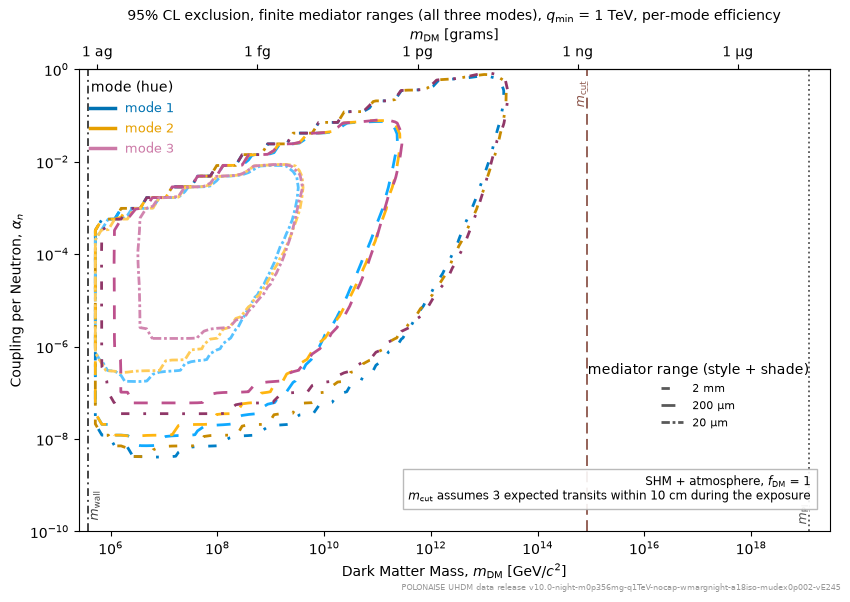

In [12]:
FINITE = [t for t in RANGES if t != "massless"]

fig, ax = plt.subplots(figsize=(8.5, 6))
drawn = []
for mode in PLOT_MODES:
    for tag in FINITE:
        d = load(mode, tag)
        if not (d["extremeness"] >= CONFIDENCE).any():
            continue
        if tag not in drawn:
            drawn.append(tag)
        ax.contour(d["ms"], d["alphas_n"], d["extremeness"],
                   levels=[CONFIDENCE], colors=[shade(mode, tag)],
                   linestyles=[STYLE[tag]], linewidths=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(XMIN_MASS, XMAX_MASS)
ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_wall(ax)
mark_m_cut(ax)
mark_planck_mass(ax, rel.axes.mass_gev[-1])
add_gram_axis(ax, XMIN_MASS, XMAX_MASS)
ttl = ("mode " + "/".join(map(str, PLOT_MODES)) if len(PLOT_MODES) < 3
       else "all three modes")
ax.set_title(f"95% CL exclusion, finite mediator ranges ({ttl}), "
             f"{Q_MIN_TXT}, per-mode efficiency", fontsize=10)

leg = ax.legend(handles=[Line2D([], [], color=BASE[m], lw=2.5, label=f"mode {m}")
                         for m in PLOT_MODES],
                loc="upper left", frameon=False, fontsize=9, title="mode (hue)")
for _t, _m in zip(leg.get_texts(), PLOT_MODES):
    _t.set_color(BASE[_m])
ax.add_artist(leg)
if drawn:
    ax.legend(handles=[Line2D([], [], color="0.35", lw=2, linestyle=STYLE[t],
                              label=LABEL[t]) for t in FINITE if t in drawn],
              loc="lower right", bbox_to_anchor=(0.985, 0.20), frameon=False,
              fontsize=8, title="mediator range (style + shade)")
ax.text(0.975, 0.06, f"SHM + atmosphere, {F_DM_TXT}\n"
        + r"$m_{\mathrm{cut}}$ " + CUT_TXT.replace("\n", " "),
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
fig.tight_layout()
save_figure(fig, "04_exclusion_modes" + "".join(map(str, PLOT_MODES)) + "_ranges")
plt.show()

## 5. Sensitivity vs mediator range, at each mode's best mass

Fixing $m_\text{DM}$ at the mass whose exclusion is **widest in the
$(\alpha_n, \lambda)$ plane** — ties broken towards reach to the shortest
mediator length, the shared criterion `luhdm.release.best_mass_index` — and
scanning the mediator range $\lambda$ against the coupling $\alpha_n$. The
excluded band is bounded below by the statistics floor, which deepens with range
and levels off at the Coulomb value once $\lambda \gtrsim$ mm (the momentum cap
stops mattering), and above by the atmospheric ceiling, which is nearly
$\lambda$-independent (atmospheric stopping is set by scattering off air nuclei,
not by the sensor). The band **pinches off** where the rising floor meets the
ceiling as $\lambda$ shrinks: below that range this mass is untestable at any
coupling.

The cube's $\lambda$ axis carries four finite ranges — far too few to draw that
band or to say where it closes. The release therefore ships a companion file for
exactly this question, `release/luhdm_lambda_scan_v10.npz`, checksummed in
`release/SHA256SUMS` alongside the two cubes. For each mode it was scanned for it
holds the optimum-interval extremeness, the expected counts and the transit counts
on a 54-point range axis running from 0.1 µm to 2 m, crossed with the same 44
couplings the cube uses, all at a single dark matter mass. This release scans
**mode 1** — the mode the Letter quotes — and the sidecar records which modes it
holds, so the panels below draw exactly those and no others. Everything in this
section is that file drawn; nothing here reaches outside the release.

Two conventions to read the panels by. The red contour is taken at the same 95%
level the release readers use, narrowed to the cubes' `float32` storage
precision so a value sitting exactly on 0.95 still counts as excluded. And the
long end of the range axis is a check rather than new information: at
$\lambda$ = 2 m the scan returns the same excluded coupling band as the cube's
massless slice, which is how the sidecar is tied to the release — its provenance
record makes the same comparison at the 20 µm, 200 µm and 2 mm slices.

In [13]:
import json

# ---- the lambda-scan sidecar: the release's companion to the cube -----------
# One npz, checksummed in release/SHA256SUMS next to the two HDF5 files. Per
# mode it carries the (alpha_n, lambda) extremeness, mu and transit-count planes
# on a 54-point mediator-range axis, 0.1 um to 2 m, at that mode's best dark
# matter mass -- the range resolution the cube's four finite slices cannot give.
# This replaces the internal full-lambda cube the figure below used to need: the
# sidecar is a released, checksummed, provenance-pinned file, so this section
# runs from a fresh checkout.
LAMBDA_SIDECAR = Path("../release/luhdm_lambda_scan_v10.npz")

# The 95% level at the release's storage-precision convention: the cubes store
# extremeness as float32, so luhdm.release narrows the level before comparing
# and a value sitting exactly on 0.95 still counts as excluded. The same level
# is used here, so this contour and the cube's excluded bands are the same test.
CONF_LEVEL = float(np.float32(CONFIDENCE))

SCAN = None
# Which modes the sidecar actually carries: it stores one plane per mode it
# was scanned for, and the modes it holds are recorded in it. This release
# scans mode 1 only, so the figures below draw mode 1 -- read off the file
# rather than assumed, so a sidecar carrying more modes draws them all.
SCAN_MODES = ()
if not LAMBDA_SIDECAR.exists():
    print(f"SKIPPED: no lambda-scan sidecar at release/{LAMBDA_SIDECAR.name}")
else:
    SCAN = np.load(LAMBDA_SIDECAR, allow_pickle=True)
    PROV = json.loads(str(SCAN["provenance"]))
    # Which cube it was scanned against, and in which scheme: both are read off
    # the sidecar's own provenance record rather than trusted, so a file scanned
    # against another cube or another analysis cannot be drawn here as if it
    # belonged to this one.
    assert PROV["cube"]["file"] == rel.path.name, \
        "the sidecar was scanned against a different released cube"
    assert PROV["physics"]["q_thresh_gev"] == float(Q_THRESH), \
        "the sidecar was scanned in a different analysis window"
    assert PROV["physics"]["b_constrained_max_m"] is None, \
        "the sidecar caps the impact-parameter integral; the release does not"
    assert PROV["physics"]["f_dm"] == F_DM, \
        "the sidecar is a different dark matter fraction"
    _sums = dict(ln.split()[::-1] for ln in
                 (LAMBDA_SIDECAR.parent / "SHA256SUMS").read_text().splitlines()
                 if len(ln.split()) == 2)
    assert LAMBDA_SIDECAR.name in _sums, \
        "the sidecar is not checksummed in SHA256SUMS"
    assert _sums[PROV["cube"]["file"]] == PROV["cube"]["sha256"], \
        "the sidecar names a cube checksum the release does not record"
    # The cube it names is the file this notebook opened, so that cube's version
    # tag is the sidecar's version too, and it stamps the figures below.
    SCAN_TAG = rel.version_tag
    SCAN_MODES = tuple(int(_m) for _m in SCAN["modes"])

    _lam, _alp = SCAN["lambda_m_mode1"], SCAN["alpha_n_mode1"]
    print(f"lambda-scan sidecar release/{LAMBDA_SIDECAR.name} ({SCAN_TAG})")
    print(f"  {_lam.size} mediator ranges {_lam[0] * 1e6:g} um .. {_lam[-1]:g} m"
          f"  x  {_alp.size} couplings   modes {list(SCAN_MODES)}   "
          f"f_DM = {PROV['physics']['f_dm']:g}, "
          + ("atmosphere on" if PROV["physics"]["atmosphere"] else "no atmosphere"))
    for _m in SCAN_MODES:
        _lm = SCAN[f"lambda_m_mode{_m}"]
        _any = (SCAN[f"extremeness_mode{_m}"] >= CONF_LEVEL).any(axis=0)
        print(f"  mode {_m}: best mass {float(SCAN[f'best_mass_gev_mode{_m}']):.4e}"
              f" GeV; 95% CL band spans lambda = {_lm[_any][0] * 1e6:.3g} um .. "
              f"{_lm[_any][-1]:g} m")


def _lam_to_m_phi(lam_m):
    """Mediator range in metres -> mediator mass in eV (top axis of the panels)."""
    lam = np.asarray(lam_m, dtype=float)
    return 1e9 / units.conv_m2pGeV(np.where(lam > 0, lam, np.nan))


def _m_phi_to_lam(m_ev):
    """The inverse. Matplotlib probes both directions at 0, hence the guard."""
    m = np.asarray(m_ev, dtype=float)
    return 1e9 / units.conv_m2pGeV(1.0) / np.where(m > 0, m, np.nan)

lambda-scan sidecar release/luhdm_lambda_scan_v10.npz (v10.0-night-m0p356mg-q1TeV-nocap-wmargnight-a18iso-mudex0p002-vE245)
  54 mediator ranges 0.1 um .. 2 m  x  44 couplings   modes [1]   f_DM = 1, atmosphere on
  mode 1: best mass 5.0194e+08 GeV; 95% CL band spans lambda = 7.96 um .. 2 m


### The excluded band against the mediator range

One line per mode the sidecar carries — mode 1 in this release: the excluded
coupling band at that mode's best mass, floor and ceiling, as the mediator range
is swept over the sidecar's 54 points. The lower panel is the same information
reduced to one number per mode — the **shortest mediator range** at which anything
is still excluded, which is where that mode's band pinches off. Reading it: the
band survives down to $\lambda$ = 7.96 µm ($m_\phi$ = 24.8 meV) and the floor
has settled onto its Coulomb value once the range is past a millimetre.

The pinch-off is the same effect that makes 20 µm floor out above 200 µm on the
mass plane. Once the range is well inside the sensor's own radius
$R_\text{eff}$ = 260 µm the largest impulse a flyby can deliver is cut down
sharply, the spectrum slides below the 1 TeV window, and the excluded band
narrows to nothing — an honest null, not a plotting gap.

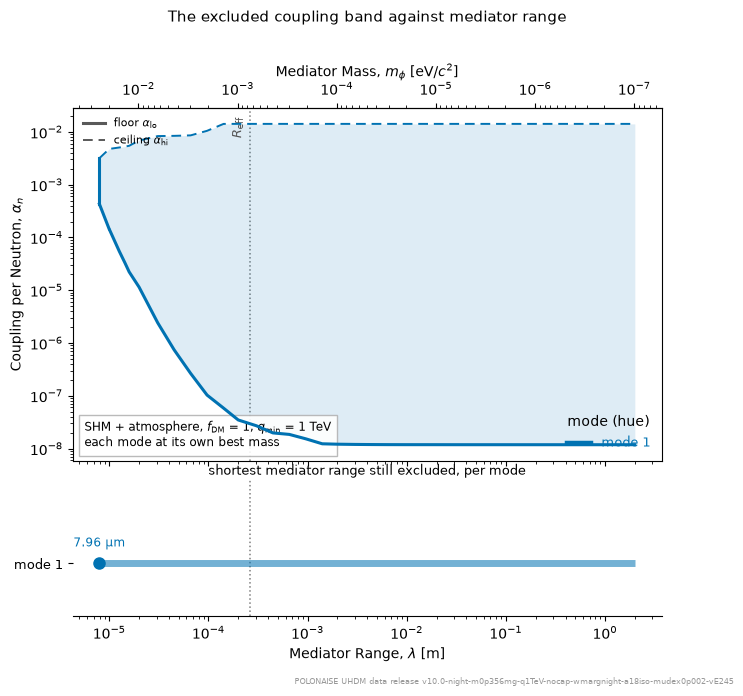

shortest mediator range with any 95% CL exclusion, per mode:
  mode 1: lambda = 7.96 um (m_phi = 0.0248 eV), at m_DM = 5.019e+08 GeV


In [14]:
def band_vs_lambda(mode, level=None):
    """(lambda, alpha_lo, alpha_hi) of the 95% band at this mode's best mass."""
    level = CONF_LEVEL if level is None else level
    lam = SCAN[f"lambda_m_mode{mode}"]
    alp = SCAN[f"alpha_n_mode{mode}"]
    p = SCAN[f"extremeness_mode{mode}"]          # (alpha_n, lambda)
    lo = np.full(lam.size, np.nan)
    hi = np.full(lam.size, np.nan)
    for i in range(lam.size):
        # the same log-interpolated edge convention as the cube's excluded_band
        lo[i], hi[i] = limits.excluded_band(alp, p[:, i], level=level)
    return lam, lo, hi


if SCAN is None:
    print("01_sensitivity_vs_range: skipped, the lambda-scan sidecar is absent")
else:
    fig, (ax, axb) = plt.subplots(
        2, 1, figsize=(7.6, 6.6), sharex=True,
        gridspec_kw=dict(height_ratios=[2.6, 1.0], hspace=0.08))

    SHORTEST = {}
    for mode in SCAN_MODES:
        lam, lo, hi = band_vs_lambda(mode)
        ok = np.isfinite(lo)
        SHORTEST[mode] = float(lam[ok][0])
        ax.fill_between(lam[ok], lo[ok], hi[ok], color=BASE[mode], alpha=0.13,
                        lw=0, zorder=2)
        ax.plot(lam[ok], lo[ok], color=BASE[mode], lw=2.2, zorder=4)
        ax.plot(lam[ok], hi[ok], color=BASE[mode], lw=1.4, ls=(0, (5, 3)),
                zorder=4)
        ax.plot([lam[ok][0]] * 2, [lo[ok][0], hi[ok][0]], color=BASE[mode],
                lw=2.2, zorder=4)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    ax.axvline(R_eff, color="#7f7f7f", lw=1.1, ls=":", zorder=1)
    ax.text(R_eff * 0.9, 0.985, r"$R_{\mathrm{eff}}$ ", color="#555555",
            fontsize=9, ha="right", va="top", rotation=90,
            transform=ax.get_xaxis_transform())
    leg = ax.legend(handles=[Line2D([], [], color=BASE[m], lw=2.5,
                                    label=f"mode {m}") for m in SCAN_MODES],
                    loc="lower right", frameon=False, fontsize=9,
                    title="mode (hue)")
    for _t, _m in zip(leg.get_texts(), SCAN_MODES):
        _t.set_color(BASE[_m])
    ax.add_artist(leg)
    ax.plot([], [], color="0.35", lw=2.2, label=r"floor $\alpha_{\rm lo}$")
    ax.plot([], [], color="0.35", lw=1.4, ls=(0, (5, 3)),
            label=r"ceiling $\alpha_{\rm hi}$")
    ax.legend(loc="upper left", fontsize=8, frameon=False)
    ax.text(0.02, 0.03, f"SHM + atmosphere, {F_DM_TXT}, {Q_MIN_TXT}\n"
            "each mode at its own best mass",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=8.5,
            bbox=dict(fc="white", ec="0.7", alpha=0.9))
    secax = ax.secondary_xaxis("top", functions=(_lam_to_m_phi, _m_phi_to_lam))
    secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV/$c^2$]")
    ax.set_title("The excluded coupling band against mediator range",
                 fontsize=11, pad=30)

    # --- the shortest excluded range, one bar per mode ---
    for k, mode in enumerate(SCAN_MODES):
        y = len(SCAN_MODES) - 1 - k
        axb.plot([SHORTEST[mode], SCAN[f"lambda_m_mode{mode}"][-1]], [y] * 2,
                 color=BASE[mode], lw=5, solid_capstyle="butt", alpha=0.55)
        axb.plot([SHORTEST[mode]], [y], "o", ms=8, color=BASE[mode], zorder=5)
        axb.text(SHORTEST[mode], y + 0.16,
                 f"{SHORTEST[mode] * 1e6:.2f} µm", color=BASE[mode],
                 fontsize=8.6, ha="center", va="bottom")
    axb.axvline(R_eff, color="#7f7f7f", lw=1.1, ls=":", zorder=1)
    axb.set_yticks(range(len(SCAN_MODES)),
                   [f"mode {m}" for m in SCAN_MODES][::-1], fontsize=9)
    axb.set_ylim(-0.6, len(SCAN_MODES) - 0.05)
    axb.set_xlabel(r"Mediator Range, $\lambda$ [m]")
    axb.set_title("shortest mediator range still excluded, per mode",
                  fontsize=9.5, pad=4)
    for s in ("top", "right", "left"):
        axb.spines[s].set_visible(False)

    save_figure(fig, "01_sensitivity_vs_range", stamp=SCAN_TAG,
                bbox_inches="tight")
    plt.show()

    print("shortest mediator range with any 95% CL exclusion, per mode:")
    for mode in SCAN_MODES:
        print(f"  mode {mode}: lambda = {SHORTEST[mode] * 1e6:.3g} um "
              f"(m_phi = {_lam_to_m_phi(SHORTEST[mode]):.3g} eV), at "
              f"m_DM = {float(SCAN[f'best_mass_gev_mode{mode}']):.3e} GeV")

### The full $(\alpha_n, \lambda)$ planes

The same file drawn as planes rather than as edges: one panel per mode the
sidecar holds, sharing the range axis, shaded by extremeness with the 95% contour
on top. The mass each mode is scanned at is stored next to its plane, so the
panels label themselves rather than repeating a number kept here. The second figure zooms on 1–20 µm,
where each mode's band pinches off.

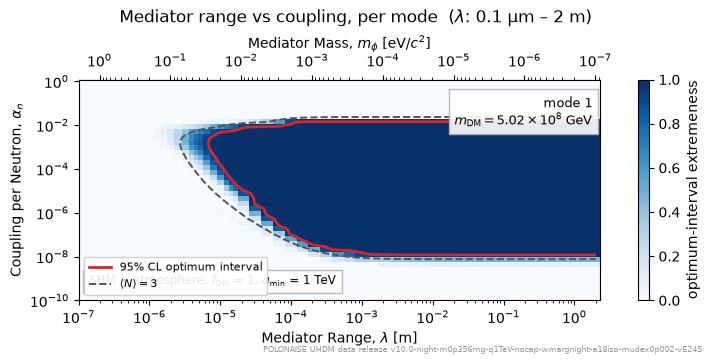

In [15]:
def mediator_panels(zoom, figname, title):
    """One panel per mode: the (alpha_n, lambda) plane at that mode's best mass."""
    if SCAN is None:
        print(f"{figname}: skipped, the lambda-scan sidecar is not present")
        return
    fig, axes = plt.subplots(len(SCAN_MODES), 1,
                             figsize=(7.0, 3.5 * len(SCAN_MODES)),
                             sharex=True, squeeze=False, constrained_layout=True)
    axes = axes[:, 0]
    mesh = None
    for row, (ax, m) in enumerate(zip(axes, SCAN_MODES)):
        lambs = SCAN[f"lambda_m_mode{m}"]
        alphas = SCAN[f"alpha_n_mode{m}"]
        sel = ((lambs >= 1e-6) & (lambs <= 2e-5)) if zoom \
            else np.ones(lambs.shape, dtype=bool)
        lam_s = lambs[sel]
        m_b = float(SCAN[f"best_mass_gev_mode{m}"])
        p = SCAN[f"extremeness_mode{m}"][:, sel]
        mu = SCAN[f"mu_mode{m}"][:, sel]
        mesh = ax.pcolormesh(lam_s, alphas, p, cmap="Blues", vmin=0, vmax=1,
                             shading="auto")
        ax.contour(lam_s, alphas, p, levels=[CONF_LEVEL], colors="#d62728",
                   linewidths=2)
        ax.contour(lam_s, alphas, mu, levels=[3.0], colors="#555555",
                   linewidths=1.4, linestyles="--")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
        e_b = int(np.floor(np.log10(m_b)))
        ax.text(0.985, 0.93, f"mode {m}\n" + rf"$m_{{\rm DM}}={m_b / 10**e_b:.2f}"
                rf"\times10^{{{e_b}}}$ GeV", transform=ax.transAxes,
                ha="right", va="top", fontsize=9,
                bbox=dict(fc="white", ec="0.7", alpha=0.9))
        if row == 0:
            secax = ax.secondary_xaxis(
                "top", functions=(_lam_to_m_phi, _m_phi_to_lam))
            secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV/$c^2$]")
    axes[-1].set_xlabel(r"Mediator Range, $\lambda$ [m]")
    axes[0].plot([], [], color="#d62728", lw=2,
                 label=f"{CONFIDENCE:.0%} CL optimum interval")
    axes[0].plot([], [], color="#555555", lw=1.4, ls="--",
                 label=r"$\langle N\rangle = 3$")
    axes[0].legend(loc="lower left", fontsize=8, framealpha=0.9)
    # the kinematic wall and the flux cut are not drawn here: both live on a
    # mass axis, and the abscissa of these panels is mediator range
    axes[-1].text(0.02, 0.06, f"SHM + atmosphere, {F_DM_TXT}, {Q_MIN_TXT}",
                  transform=axes[-1].transAxes, ha="left", va="bottom",
                  fontsize=8.5, bbox=dict(fc="white", ec="0.7", alpha=0.9))
    fig.colorbar(mesh, ax=list(axes), label="optimum-interval extremeness")
    fig.suptitle(title, fontsize=12)
    # leave a strip along the bottom for the release stamp, which sits outside
    # the layout engine's reckoning and would otherwise land on the x label
    fig.get_layout_engine().set(rect=(0.0, 0.014, 1.0, 0.986))
    save_figure(fig, figname, stamp=SCAN_TAG)
    plt.show()


mediator_panels(False, "04_mediator_vs_coupling",
                r"Mediator range vs coupling, per mode  ($\lambda$: 0.1 µm – 2 m)")

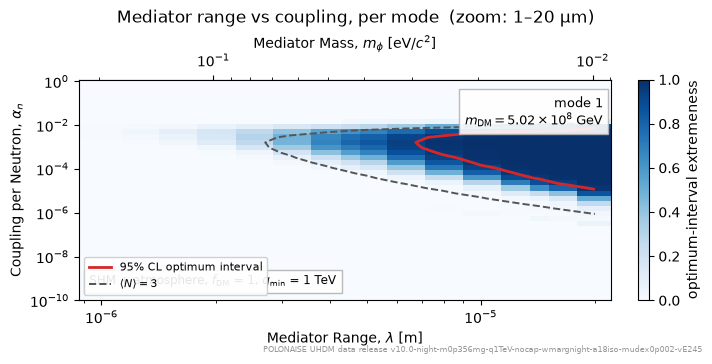

In [16]:
mediator_panels(True, "04_mediator_vs_coupling_zoom",
                r"Mediator range vs coupling, per mode  (zoom: 1–20 µm)")

## Machine-readable output

Every surface, contour, and event list on the plots above lives in the
POLONAISE UHDM **data release** (the current release cube — see the version
tag in the file / `release/README.md`), read here
through `luhdm.release`. See
[`05_using_the_data_release.ipynb`](05_using_the_data_release.ipynb) for the schema, the loader API,
and how to pull any slice (including the raw-HDF5 route with no luhdm code).

## Notes

- **Data**: replace `data_mode{n}.txt` and re-run. More candidates only move
  the extremeness surfaces; the machinery is untouched.
- Every surface here is precomputed once by **`scripts/build_release.py`** (the
  per-$\lambda$ cube builder, run on a many-core node) and assembled into the
  HDF5 data release by **`scripts/assemble_release.py`**; the mediator-range
  planes of section 5 come from **`scripts/scan_lambda.py`**, gathered into the
  sidecar by **`scripts/assemble_lambda_sidecar.py`**. This notebook only
  *reads* them — through **`luhdm.release`** for the cubes, straight out of the
  npz for the sidecar — so notebook and cluster runs cannot drift. The
  underlying physics lives in **`luhdm/rate.py`** and the fiducials in
  **`luhdm/config.py`** (threshold, exposure, $f_X$, …).
- The $\langle N\rangle \simeq 3$ dashed contour is the zero-candidate rule; the
  solid optimum-interval contour reduces to it only where no candidate falls in
  the kinematic window.
- To draw one mode in the three-mode figures, set `PLOT_MODES = (1,)` and
  re-run: those filenames carry the selection, so a single-mode run does not
  overwrite the three-mode figures. The mediator-range panels are the exception
  — they draw whichever modes the lambda-scan sidecar was scanned for (mode 1 in
  this release), read off the file rather than set here.
- Every cell here reads a released file: the two cubes, the refined-contour
  sidecar and the lambda-scan sidecar are checksummed together in
  `release/SHA256SUMS`, so this notebook runs start to finish from a fresh
  checkout with nothing internal on hand.